# Preamble

## Imports

In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import json
import h5py
import os

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model

## Useful Functions

In [2]:
def Sigma_LBP_1(r,Mdisk,Rc) -> float:
    val = (Mdisk)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

In [3]:
# Set notebook name (change this when copying to a new notebook)
_NOTEBOOK_NAME = "CASCA_planets_psiConstant copy 7"
_NOTEBOOK_DIR = os.getcwd()
_OUTPUT_DIR = os.path.join(_NOTEBOOK_DIR, 'output', _NOTEBOOK_NAME)

def savefig(filename, subfolder=None, dpi=250, **kwargs):
    """Save the current figure under <notebook_dir>/output/<notebook_name>/[subfolder]/filename.
    If a file with the same name exists, appends _1, _2, _3, etc. to avoid overwriting."""
    if subfolder:
        save_dir = os.path.join(_OUTPUT_DIR, subfolder)
    else:
        save_dir = _OUTPUT_DIR
    
    # Split filename into base and extension
    base, ext = os.path.splitext(filename)
    save_path = os.path.join(save_dir, filename)
    
    # If file exists, find next available number
    counter = 1
    while os.path.exists(save_path):
        new_filename = f"{base}_{counter}{ext}"
        save_path = os.path.join(save_dir, new_filename)
        counter += 1
    
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(save_path, dpi=dpi, **kwargs)
    print(f"Saved: {save_path}")

In [4]:
def save_history_hdf5(filename, history, torque_maps, disc, params=None):
    # If the file already exists, append _1, _2, _3, ... before the extension
    base, ext = os.path.splitext(filename)
    counter = 1
    while os.path.exists(filename):
        filename = f"{base}_{counter}{ext}"
        counter += 1

    # Make sure the target directory exists
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    with h5py.File(filename, 'w') as f:
        # static disc grid (same for all snapshots)
        f.create_dataset('R', data=disc.R)                       # AU, cell centres

        # scalar-per-snapshot fields -> 1D arrays
        for key in ['t_yr', 'Mtot', 'Rout', 'Mdot_star', 'R_dz']:
            f.create_dataset(key, data=np.array(history[key]))

        # profile-per-snapshot fields -> 2D arrays (n_snaps, Ncells)
        for key in ['Sigma_G', 'Sigma_D', 'dust_frac', 'St',
                    'grain_size', 'T', 'P', 'mid_gas_dens']:
            f.create_dataset(key, data=np.array(history[key]))

        # chemistry (n_snaps, n_species, Ncells)
        f.create_dataset('chem_ice', data=np.array(history['chem_ice']))
        f.create_dataset('chem_gas', data=np.array(history['chem_gas']))

        # Mdot_r / R_faces (n_snaps, Ncells-1)
        f.create_dataset('Mdot_r',  data=np.array(history['Mdot_r']))
        f.create_dataset('R_faces', data=np.array(history['R_faces']))

        # planets: ragged early on (0 planets), so store only snapshots that have them
        g = f.create_group('planets')
        first = next((s for s in range(len(history['planets_R']))
                      if len(history['planets_R'][s]) > 0), None)
        if first is not None:
            g.attrs['first_snap'] = first
            g.create_dataset('R',     data=np.array(history['planets_R'][first:]))
            g.create_dataset('Mcore', data=np.array(history['planets_Mcore'][first:]))
            g.create_dataset('Menv',  data=np.array(history['planets_Menv'][first:]))

        # torque maps (n_maps, n_mass, n_R)
        t = f.create_group('torque_maps')
        t.create_dataset('t_yr', data=np.array(torque_maps['t_yr']))
        t.create_dataset('maps', data=np.array(torque_maps['maps']))

        if params is not None:
            f.attrs['params_json'] = json.dumps(params)

    return filename   # the path actually written (may be numbered)


#save_path = os.path.join(_OUTPUT_DIR, subfolder, 'run_data.h5')
#written = save_history_hdf5(save_path, history, torque_maps, disc, params)
#print(f"Saved {written}")

In [5]:
def load_history_hdf5(filename):
    """Load a run saved with save_history_hdf5.

    Returns
    -------
    history : dict      reconstructed time-series (same keys as the run)
    torque_maps : dict  {'t_yr', 'maps'}
    R : ndarray         disc cell-centre radii [AU]
    params : dict or None  the saved parameter dict
    """
    history = {}
    torque_maps = {}

    with h5py.File(filename, 'r') as f:
        R = f['R'][:]

        # scalar-per-snapshot and profile-per-snapshot fields
        for key in ['t_yr', 'Mtot', 'Rout', 'Mdot_star', 'R_dz',
                    'Sigma_G', 'Sigma_D', 'dust_frac', 'St',
                    'grain_size', 'T', 'P', 'mid_gas_dens',
                    'chem_ice', 'chem_gas', 'Mdot_r', 'R_faces']:
            if key in f:
                history[key] = f[key][:]

        # planets: stored only from first implanted snapshot onward.
        # Re-pad earlier snapshots with empty arrays so indices line up
        # with t_yr and the plotting cell's `first_snap` logic still works.
        n_snaps = len(history['t_yr'])
        history['planets_R']     = [np.array([]) for _ in range(n_snaps)]
        history['planets_Mcore'] = [np.array([]) for _ in range(n_snaps)]
        history['planets_Menv']  = [np.array([]) for _ in range(n_snaps)]
        if 'planets' in f and 'R' in f['planets']:
            first = f['planets'].attrs['first_snap']
            pl_R     = f['planets/R'][:]
            pl_Mcore = f['planets/Mcore'][:]
            pl_Menv  = f['planets/Menv'][:]
            for j in range(pl_R.shape[0]):
                history['planets_R'][first + j]     = pl_R[j]
                history['planets_Mcore'][first + j] = pl_Mcore[j]
                history['planets_Menv'][first + j]  = pl_Menv[j]

        # torque maps
        if 'torque_maps' in f:
            torque_maps['t_yr'] = f['torque_maps/t_yr'][:]
            torque_maps['maps'] = f['torque_maps/maps'][:]

        # params
        params = None
        if 'params_json' in f.attrs:
            params = json.loads(f.attrs['params_json'])

    return history, torque_maps, R, params

In [6]:
#old, might need updates
def compute_alpha_turb_array(R, H, R_dz, alpha_dead, alpha_active, width_factor=1.0):
    """
    Creates a smooth alpha_turb array that transitions at R_dz.
    Transitions in log-space to ensure smooth orders of magnitude.
    
    Args:
        R: radial grid (array, AU)
        H: scale height (array, AU)
        R_dz: dead zone radius (scalar, AU)
        alpha_dead: turbulent alpha in dead zone
        alpha_active: turbulent alpha in active zone
        width_factor: transition width in units of H at R_dz
    """

    log_a_dead = np.log10(alpha_dead)
    log_a_active = np.log10(alpha_active)

    # Find the exact scale height (H) at the deadzone boundary
    H_at_rdz = np.interp(R_dz, R, H)
    
    # Tanh transition: 0 in dead zone, 1 in active zone
    transition = 0.5 * (1.0 + np.tanh((R - R_dz) / (width_factor * H_at_rdz)))
    
    # Blend in log space
    log_alpha_array = log_a_dead + transition * (log_a_active - log_a_dead)
    
    return 10**log_alpha_array

In [7]:
#old, might need updates
def compute_R_dz_linear(t_yr, R_dz_initial_AU, R_dz_min_AU, t_start_yr, t_final_yr) -> float: 
    """
    Moves Rdz linearly from initial to min over the disc lifetime.
    """

    disc_lifetime_yr = t_final_yr - t_start_yr
    distance = R_dz_initial_AU.value - R_dz_min_AU.value 
    velocity = distance / disc_lifetime_yr #Au/yr 
    t_rel = max(0.0, t_yr - t_start_yr)

    return max(R_dz_initial_AU.value - (velocity * t_rel), R_dz_min_AU.value) 

In [8]:
def compute_R_dz_exponential(t, r_floor, r_0, r_1, t0, t1):
    """
    Exponentially moves the dead-zone radius inward.

    Parameters
    ----------
    t : float
        Time in yr.
    r_floor : float
        Minimum/final dead-zone radius in AU.
    r_0 : float
        Dead-zone radius at t0 in AU.
    r_1 : float
        Dead-zone radius at t1 in AU.
    t0 : float
        Initial reference time in yr.
    t1 : float
        Benchmark time in yr.

    Returns
    -------
    R_dz : float
        Dead-zone radius in AU.
    """

    if not (r_floor < r_1 < r_0):
        raise ValueError("Need r_floor < r_1 < r_0 for inward exponential decay.")

    if t1 <= t0:
        raise ValueError("Need t1 > t0.")

    tau = -(t1 - t0) / np.log((r_1 - r_floor) / (r_0 - r_floor))

    # prevent R_dz from exceeding r_0 before t0
    if t <= t0:
        return r_0

    R_dz = r_floor + (r_0 - r_floor) * np.exp(-(t - t0) / tau)

    return R_dz

# 0. Simulation Parameters

In [9]:
t_initial = 0.0 * u.Myr
t_initial_yr = t_initial.to(u.yr).value 
t_initial_code = t_initial_yr * yr_code  #Convert to code units

t_final = 1.0 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.1 * u.solMass 
Rc = 50.0 * u.AU #where disc starts fading out at 0.1 Myr in order to be at 120 AU at 1Myr
Mstar = 1.0 * u.solMass
Rstar = 2.5 * u.solRad
Tstar = 4000.0 * u.K
mu = 2.33

#Reference Values
Mdot_ref = 1e-8
alpha_SS = 1e-4
psi = 10

# Create descriptive subfolder name
subfolder = f'psi10_diskmass_{M_disk_0.value:.2f}_alphaSS_{alpha_SS:.0e}_Mdot_{Mdot_ref:.1e}'

In [10]:
#Collect simulation parameters (will be saved after grid is defined)
params = {
    "time": {
        "t_initial_Myr": t_initial.value,
        "t_final_Myr": t_final.value,
    },
    "disc": {
        "M_disk_0_Msun": M_disk_0.value,
        "Rc_AU": Rc.value
    },
    "star": {
        "Mstar_Msun": Mstar.value,
        "Rstar_Rsun": Rstar.value,
        "Tstar_K": Tstar.value
    },
    "physics": {
        "Mdot_ref_Msun_per_yr": Mdot_ref,
        "alpha_SS": alpha_SS
    },
    "output": {
        "subfolder": subfolder,
        "notebook_name": _NOTEBOOK_NAME
    }
}

# 1. Grid

In [11]:
R_in = 0.1   # AU
R_out = 1000.0  # AU — must be >> Rc (91 AU) so the spreading front never reaches the boundary
Ncells = 1000
grid = Grid(R_in, R_out, Ncells, spacing='natural')
R_centers = grid.Rc  # AU

In [12]:
#Update and save complete simulation parameters to JSON
params["disc"]["R_in_AU"] = R_in
params["disc"]["R_out_AU"] = R_out
params["disc"]["Ncells"] = Ncells

#Save to JSON file in output directory
params_path = os.path.join(_OUTPUT_DIR, subfolder, 'simulation_parameters.json')
os.makedirs(os.path.dirname(params_path), exist_ok=True)
with open(params_path, 'w') as f:
    json.dump(params, f, indent=2)

# 2. Star

In [13]:
star = SimpleStar(M = Mstar.value ,      #Msun
                  R = Rstar.value,       #Rsun
                  T_eff = Tstar.value,   #K
                  age = t_initial_yr)    #yr

# 3. EOS

In [14]:
eos = IrradiatedEOS(
   star,
    alpha_t=alpha_SS,   
    Tc=10,                  #External/nebular temperature floor (K)
    Tmax=1500,              #max temperature cap (K)
    mu=mu,
    #gamma=1.0,
    accrete=True,           #Include viscous heating from accretion
    kappa=Zhu2012,
    e_rad= 0.9, #0.99 Maybe given new data
    psi = psi
)

#eos = SimpleDiscEOS(alpha_t=alpha_SS, star=star,mu=mu)
#eos = SimpleDiscEOS(star, alpha_t=alpha_SS)
eos.set_grid(grid)

Initial EOS solve to get zero timestep and initial LBP profile

In [15]:
#LBP profile
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU, M_disk_0, Rc).value for r in R_centers])

#Set this profile as timezero
eos.update(0, Sigma_initial)

# 4. Disc 

In [16]:
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              #Initial dust-to-gas ratio
    Sigma=Sigma_initial,
    feedback=True,         #Dust affects gas dynamics
    f_ice=1,               #Ice fraction (affects fragmentation)
    uf_0=500,              #Fragmentation velocity for dry grains (cm/s)
    uf_ice=500,           #Fragmentation velocity for icy grains (cm/s)
    thresh=0.5             #Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0)           #This is to have the pebble size and stokes number correct at t=0

# 5. Viscous Evolution

In [17]:
visc_evol = HybridWindModel(psi_DW=psi, 
                            lambda_DW=3.0, 
                            tol=0.5, 
                            boundary='power_law', 
                            in_bound='Mdot')

disc._gas = visc_evol #Attach to _gas object

# 6. Chemistry 

In [18]:
chem_model = EquilibriumCOChemOberg(fix_ratios=False, a=1e-5)

#Set solar abundances
X_solar = SimpleCOAtomAbund(disc.Ncells)
X_solar.set_solar_abundances()

#Iterate to convergence (ice fraction changes dust-to-gas ratio)
for i in range(10):
    chem = chem_model.equilibrium_chem(
        disc.T, 
        disc.midplane_gas_density,
        disc.dust_frac.sum(0), 
        X_solar
    )
    disc.initialize_dust_density(chem.ice.total_abund)

#Attach to disc
disc.chem = chem
disc.update_ices(disc.chem.ice)

# 7. Fluid Drift

In [19]:
drift = SingleFluidDrift(
                        diffusion=TracerDiffusion(Sc=1,limit=False),
                        settling=True,
                        van_leer=True)

# 8.5 Planets

In [20]:
planets = Planets(Nchem=0)  # or Nchem=disc.chem.ice.data.shape[0] if tracking chemistry

planet_model = Bitsch2015Model(disc, 
                                pb_gas_f=0.1, 
                                migrate=True, 
                                pebble_acc=True, 
                                gas_acc=True, 
                                winds=True)
planet_model.set_disc(disc)

In [21]:
implant_time_yr = 0.06e6 #0.06 Myr 
planets_implanted = False


planets_params = [ #AU, M_E, M_E
    {'R': 1.0,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 1.5,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 2.0,  'Mcore': 0.01, 'Menv': 0.0},
    {'R': 3.0, 'Mcore': 0.01, 'Menv': 0.0},
    {'R': 4.0,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 5.0,  'Mcore': 0.01, 'Menv': 0.0},
    {'R': 6.0,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 7.0, 'Mcore': 0.01, 'Menv': 0.0},
    {'R': 8.5,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 10.0,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 12.5,  'Mcore': 0.01,  'Menv': 0.0},
    {'R': 15.0,  'Mcore': 0.01, 'Menv': 0.0},
    {'R': 20.0, 'Mcore': 0.01, 'Menv': 0.0},
    {'R': 25.0, 'Mcore': 0.01, 'Menv': 0.0},
    {'R': 30.0, 'Mcore': 0.01, 'Menv': 0.0},
] 

In [22]:
driver = PlanetDiscDriver(
    disc, 
    gas=visc_evol, 
    dust=drift,
    chemistry=chem_model,
    planets=planets,
    planet_model=planet_model,
    t0=t_initial_code
)

# 9. Evolution Setup

## 9.1 runtime + output times

In [23]:
run_start_yr = t_initial_yr
run_end_yr = t_final_yr
run_duration_yr = run_end_yr - run_start_yr

output_times_yr = np.linspace(run_start_yr, run_end_yr, 10)
output_times_code = output_times_yr * yr_code

io = Event_Controller(save=output_times_code)

## 9.2 Data arrays

In [24]:
history = { 
    't_yr': [],
    'Mtot': [], 
    'Rout': [],  
    'Rc': [], 
    'Sigma_G': [], 
    'Sigma_D': [], 
    'dust_frac': [], 
    'St': [], 
    'grain_size': [], 
    'T': [], 
    'P': [], 
    'chem_ice': [], 
    'chem_gas': [], 
    'mid_gas_dens': [],
    'Mdot_star': [],
    'Mdot_r': [],                          #Mdot profile at internal cell faces [Msun/yr], shape (n_snaps, Ncells-1)
    'R_faces': [],
    'R_dz': [],
    'planets_R': [],
    'planets_Mcore': [],
    'planets_Menv': [],
}

torque_maps = {
    't_yr': [],
    'maps': []
}

planet_log = {'step': [], 't_yr': [], 'R': [], 'Mcore': [], 'Menv': []}

#Create M-R diagram for torque maps
mass_array = np.logspace(-2,3,Ncells)                   #Mearth required by compute_torque function
radius_array = disc.R                                   #AU                               
R_grid, M_grid = np.meshgrid(radius_array, mass_array)  #2D grid from the two 1D arrays

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/Alpha_profiles_1.png


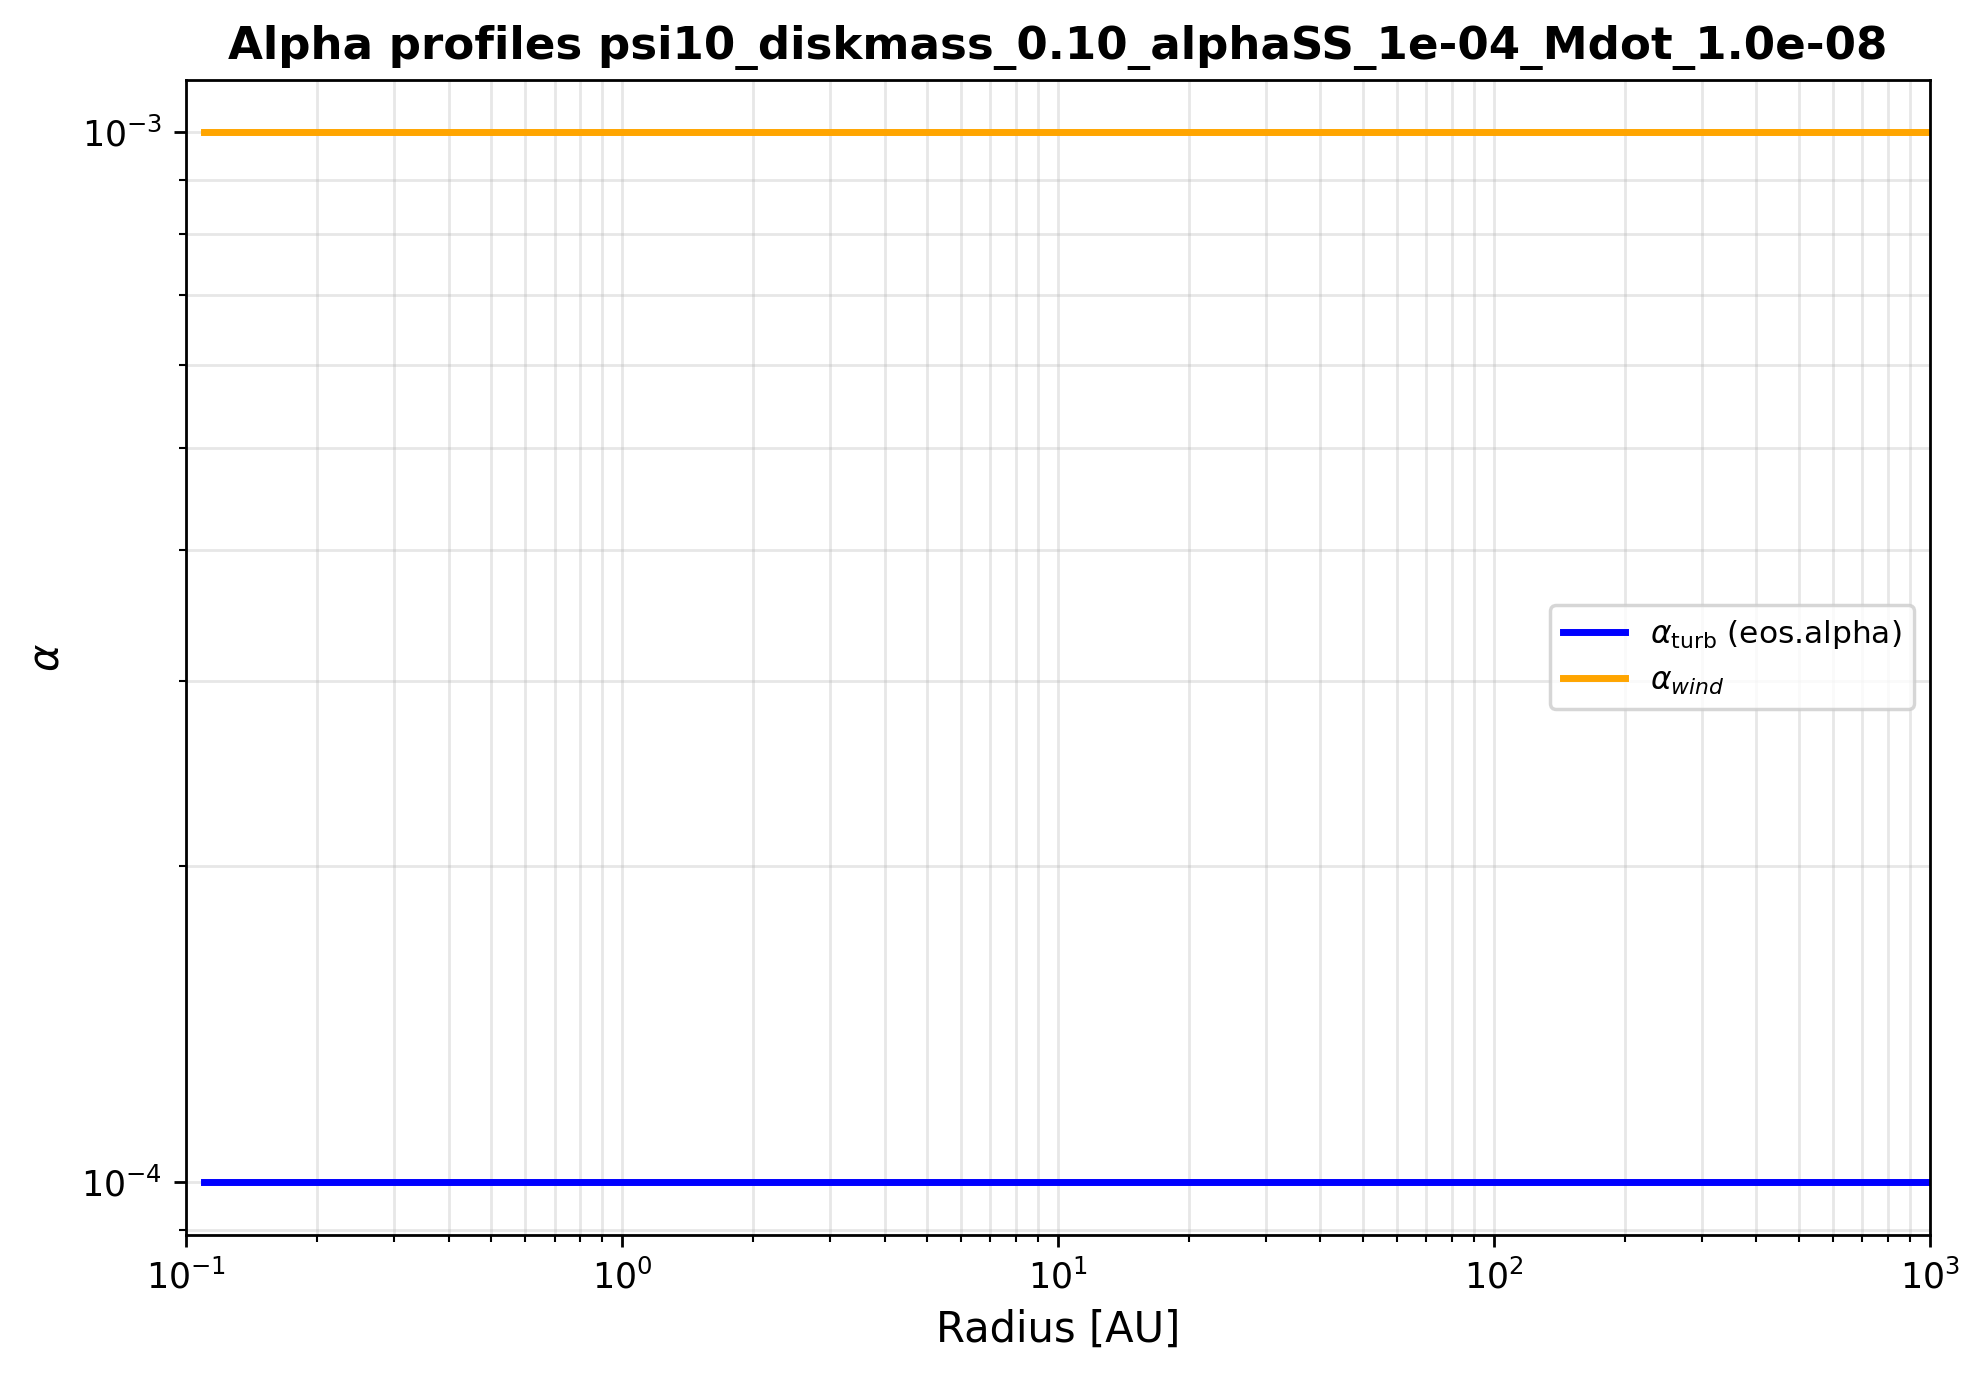

In [25]:
fig, ax = plt.subplots(figsize=(9, 6), dpi = 250)

ax.loglog(disc.R, alpha_SS * np.ones_like(disc.R), label=r'$\alpha_{\rm turb}$ (eos.alpha)', lw=2, color='blue')
ax.loglog(disc.R, psi * alpha_SS * np.ones_like(disc.R), label=r'$\alpha_{wind}$', lw=2, color='orange')
#ax.loglog(Rgrid, alpha_eff_arr, label=r'$\alpha_{\rm eff}$ ($\alpha_{\rm turb}(1+\psi)$)', lw=2, color='red')
#ax.loglog(Rgrid, alpha_from_nu, label=r'$\nu / (c_s H)$ (back-calculated)', lw=1, ls='--', color='lime')

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(r'$\alpha$', fontsize=12)
ax.set_title(r'Alpha profiles '+subfolder, fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(R_in, R_out)

savefig('Alpha_profiles.png', subfolder) 
plt.show()

# 10. Initial Plots

## 10.1 Plotting functions

In [26]:
def plot_disc_values() -> None:
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    #color gradient
    n_snaps = len(history['t_yr'])
    alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

    # Deadzone radii
    rdz = history['R_dz']

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = history['Sigma_G']
    Sd = history['Sigma_D']
    for i, line in enumerate(Sg):
        ax.loglog(disc.R, Sg[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    for i, line in enumerate(Sd):
        ax.loglog(disc.R, Sd[i], linestyle='dashed', color='C1', alpha=alphas[i], lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = history['dust_frac']
    for i, line in enumerate(d2g):
        ax.loglog(disc.R, d2g[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    

    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 3. Stokes number
    ax = axes[0, 2]
    St = history['St']
    for i, line in enumerate(St):
        ax.loglog(disc.R, St[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 4. Pebble size
    ax = axes[1, 0]
    a = history['grain_size']
    for i, line in enumerate(a):
        ax.loglog(disc.R, a[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
    
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(history['P'])
    for i, line in enumerate(P):
        ax.loglog(disc.R, P[i], linestyle='solid', color='C0', alpha=alphas[i],
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)

    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 6. Temperature profile
    ax = axes[1, 2]
    T = history['T']
    for i, line in enumerate(T):
        ax.loglog(disc.R, T[i], linestyle='solid', color='C0', alpha=alphas[i], lw=lw)
        
    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 2e3)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    plt.suptitle('Disc Values '+subfolder, fontsize=14)
    plt.tight_layout()
    savefig('disc_values.png', subfolder)
    plt.show()

In [27]:
def plot_disc_initial_values() -> None:
    #fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    lw = 1.5

    #color gradient
    n_snaps = len(history['t_yr'])
    alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

    # 1. Surface density: Gas and Dust
    ax = axes[0, 0]
    Sg = history['Sigma_G']
    Sd = history['Sigma_D']
    for i, line in enumerate(Sg):
        ax.loglog(disc.R, Sg[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    for i, line in enumerate(Sd):
        ax.loglog(disc.R, Sd[i], linestyle='dashed', color='C1', alpha=1, lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
    ax.set_title('Surface Density')
    ax.legend(fontsize=8)
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(max(np.max(Sg), np.max(Sd))))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)

    # 2. Dust-to-gas ratio (epsilon)
    ax = axes[0, 1]
    d2g = history['dust_frac']
    for i, line in enumerate(d2g):
        ax.loglog(disc.R, d2g[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$\epsilon$')
    ax.set_title('Total Dust/Gas Ratio')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(1e-6, 10**(np.ceil(np.log10(np.max(d2g)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    #ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 3. Stokes number
    ax = axes[0, 2]
    St = history['St']
    for i, line in enumerate(St):
        ax.loglog(disc.R, St[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Stokes Number')
    ax.set_title('Stokes Number')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(St)))), 10**(np.ceil(np.log10(np.max(St)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    #ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 4. Pebble size
    ax = axes[1, 0]
    a = history['grain_size']
    for i, line in enumerate(a):
        ax.loglog(disc.R, a[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('Pebble Size [cm]')
    ax.set_title('Pebble Size')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(a)))), 10**(np.ceil(np.log10(np.max(a)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    #ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 5. Pressure
    ax = axes[1, 1]
    P = np.abs(history['P'])
    for i, line in enumerate(P):
        ax.loglog(disc.R, P[i], linestyle='solid', color='C0', alpha=1,
                  label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=lw)
        if i >= 0:
            break
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('|P|')
    ax.set_title('Pressure')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(P)))), 10**(np.ceil(np.log10(np.max(P)))))
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    #ax.axvline(R_dz.value, ls = ':', color = 'red')

    # 6. Temperature profile
    ax = axes[1, 2]
    T = history['T']
    for i, line in enumerate(T):
        ax.loglog(disc.R, T[i], linestyle='solid', color='C0', alpha=1, lw=lw)
        if i >= 0:
            break
    ax.axhline(170, ls='dashed', label='170 K', color='gray', lw=1)
    ax.legend(fontsize=8)
    ax.set_xlabel('R [AU]')
    ax.set_ylabel('T [K]')
    ax.set_title('Temperature Profile')
    ax.set_xlim(R_in, R_out)
    ax.set_ylim(10**(np.floor(np.log10(np.min(T)))), 2e3)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', length=2)
    #ax.axvline(R_dz.value, ls = ':', color = 'red')

    plt.suptitle('Disc Values '+subfolder, fontsize=14)
    plt.tight_layout()
    savefig('disc_values.png', subfolder)
    plt.show()


# 11. Evolution Loop

In [28]:
pbar = tqdm(total=run_duration_yr,
             unit='yr',
             desc='Evolving disc... ',
             bar_format='{desc}: {percentage:.1f}%|{bar}| {rate_fmt} [{elapsed}<{remaining}]')
last_elapsed_yr = 0.0
steps = 0
t_yr = driver.t / yr_code
last_t_yr = t_yr

while not io.finished():
    ti = io.next_event_time()

    while driver.t < ti:
        """ # Here is stuff needed to make DZ move inwards
        t_yr_current = driver.t / yr_code
        
        # Compute current DZ radius
        R_dz_current = compute_R_dz_exponential(
                                                t_yr_current, 
                                                r_dz_floor, #params set in section 0
                                                r_dz_0, 
                                                r_dz_1, 
                                                t_dz_0, 
                                                t_dz_1)

        R_dz_current = compute_R_dz_linear(t_yr_current,
                                        R_dz_initial_AU=R_dz, 
                                        R_dz_min_AU=0.1 * u.AU,
                                        t_start_yr=t_initial_yr,
                                        t_final_yr=t_final_yr)

        # Rebuild alpha_SS array with new DZ location
        alpha_SS_arr[:] = compute_alpha_turb_array(
                                                R=disc.R, 
                                                H=eos.H, 
                                                R_dz=R_dz_current,
                                                alpha_dead=alpha_SS_DZ, 
                                                alpha_active=alpha_SS_AZ, 
                                                width_factor=2)   

        # Recompute the psi array 
        psi_arr[:] = alpha_DW_arr / alpha_SS_arr

        # Assign new arrays to the eos and wind parameters 
        #eos._alpha_t = alpha_SS_arr ##
        #visc_evol._psi = psi_arr   ##These lines are useless since we don't create new array objects only update the ones the modules point to already

 """

        ## Planets Stuff
        if not planets_implanted and (driver.t / yr_code) >= implant_time_yr:
            for p in planets_params:
                planets.add_planet(driver.t, R=p['R'], Mcore=p['Mcore'], Menv=p['Menv'])  #This will mutate the planets reference in the driver
                print('Planet implanted at '+str(p['R'])+' AU.')
            planets_implanted = True

        # below is necessary stuff to evolve disc with constant DZ
        dt = driver(ti)
        steps += 1

         # --- log planet data every 5 steps ---
        if planets_implanted and steps % 5 == 0:
            planet_log['step'].append(steps)
            planet_log['t_yr'].append(driver.t / yr_code)
            planet_log['R'].append(planets.R.copy())
            planet_log['Mcore'].append(planets.M_core.copy())
            planet_log['Menv'].append(planets.M_env.copy())

        # pbar progress
        t_yr = driver.t / yr_code
        pbar.update(t_yr - last_t_yr)
        last_t_yr = t_yr

    # Store at output times
    if io.check_event(driver.t, 'save'):
        history['t_yr'].append(driver.t / yr_code)                        #yr
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))           #Msol
        history['Rout'].append(disc.Rout())                               #AU
        #history['Rc'].append(disc.RC())                                  #AU
        history['Sigma_G'].append(disc.Sigma_G.copy())                    #Total gas Sigma
        history['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy())        #Total dust Sigma, pebbles + grains
        history['dust_frac'].append(disc.dust_frac.sum(axis=0).copy())    #Total dust to gas ratio
        history['St'].append(disc.Stokes()[1].copy())                     #Pebbles not small grains
        history['grain_size'].append(disc.grain_size[1].copy())           #Pebbles not small grains
        history['T'].append(disc.T.copy())                                #Temperature
        history['P'].append(disc.P.copy())                                #Pressure
        history['chem_ice'].append(disc.chem.ice.data.copy())             
        history['chem_gas'].append(disc.chem.gas.data.copy())
        history['mid_gas_dens'].append(disc.midplane_gas_density.copy())
        
        vr = visc_evol.viscous_velocity(disc)                                       #AU/code_time, Ncells-1 internal faces
        Sig_faces  = (disc.Sigma[:-1] + disc.Sigma[1:]) / 2                                 #face-averaged total Sigma [g/cm^2], skips inner edge and outer edge
        R_faces = disc.grid.Re[1:-1]                                                        #faces Radii, skips inner edge and outer edge
        history['R_faces'].append(R_faces.copy())

        history['Mdot_star'].append(disc.Mdot(vr[0]))                                  #Msun/yr at innermost face, conversion happens inside disc.Mdot()
        history['Mdot_r'].append(                                                           #Msun/yr at all faces, except innermost
            (-2.0 * np.pi * R_faces * Sig_faces * vr * AU**2 * yr_code / Msun).copy()  #same form as what goes on in disc.Mdot()
        )

        """ history['R_dz'].append(compute_R_dz_exponential(
                                                driver.t / yr_code, 
                                                r_dz_floor, #params set in section 0
                                                r_dz_0, 
                                                r_dz_1, 
                                                t_dz_0, 
                                                t_dz_1)
        ) """

        """ history['R_dz'].append(compute_R_dz_linear(driver.t / yr_code,
                                        R_dz_initial_AU=R_dz, 
                                        R_dz_min_AU=0.1 *u.AU,
                                        t_start_yr=t_initial_yr,
                                        t_final_yr=t_final_yr)
        ) """
        
        #history['R_dz'].append(R_dz_current)

        history['planets_R'].append(planets.R.copy())
        history['planets_Mcore'].append(planets.M_core.copy())
        history['planets_Menv'].append(planets.M_env.copy())

        io.pop_events(driver.t, 'save')

        #Torque Maps Data 
        TypeI = pf.TypeIMigration(disc)                                                     #Creates a Type I migration object from the disc object
        Torque_map = np.zeros_like(R_grid)                                                  #initialize 2D grid with all values zero 

        for i, Mp in enumerate(mass_array):
            Mp_array = np.ones_like(radius_array) * Mp                                      #Pass Mp as an array of the same shape as radius_array           
            Torque_map[i,:] = TypeI.compute_torque_not_normalized(radius_array, Mp_array)   #Compute the total torque for said mass at each R 

        torque_maps['t_yr'].append(driver.t / yr_code)
        torque_maps['maps'].append(Torque_map)

pbar.close()


print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")

Evolving disc... : 0.0%|          | ?yr/s [00:00<?]

Planet implanted at 1.0 AU.
Planet implanted at 1.5 AU.
Planet implanted at 2.0 AU.
Planet implanted at 3.0 AU.
Planet implanted at 4.0 AU.
Planet implanted at 5.0 AU.
Planet implanted at 6.0 AU.
Planet implanted at 7.0 AU.
Planet implanted at 8.5 AU.
Planet implanted at 10.0 AU.
Planet implanted at 12.5 AU.
Planet implanted at 15.0 AU.
Planet implanted at 20.0 AU.
Planet implanted at 25.0 AU.
Planet implanted at 30.0 AU.

=== EVOLUTION COMPLETE ===
Total steps: 126219
Final time: 1.0e+06 years
Final mass: 8.150e-02 M_sun (81.7% of initial)


# 12. Final Plots

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/disc_values.png


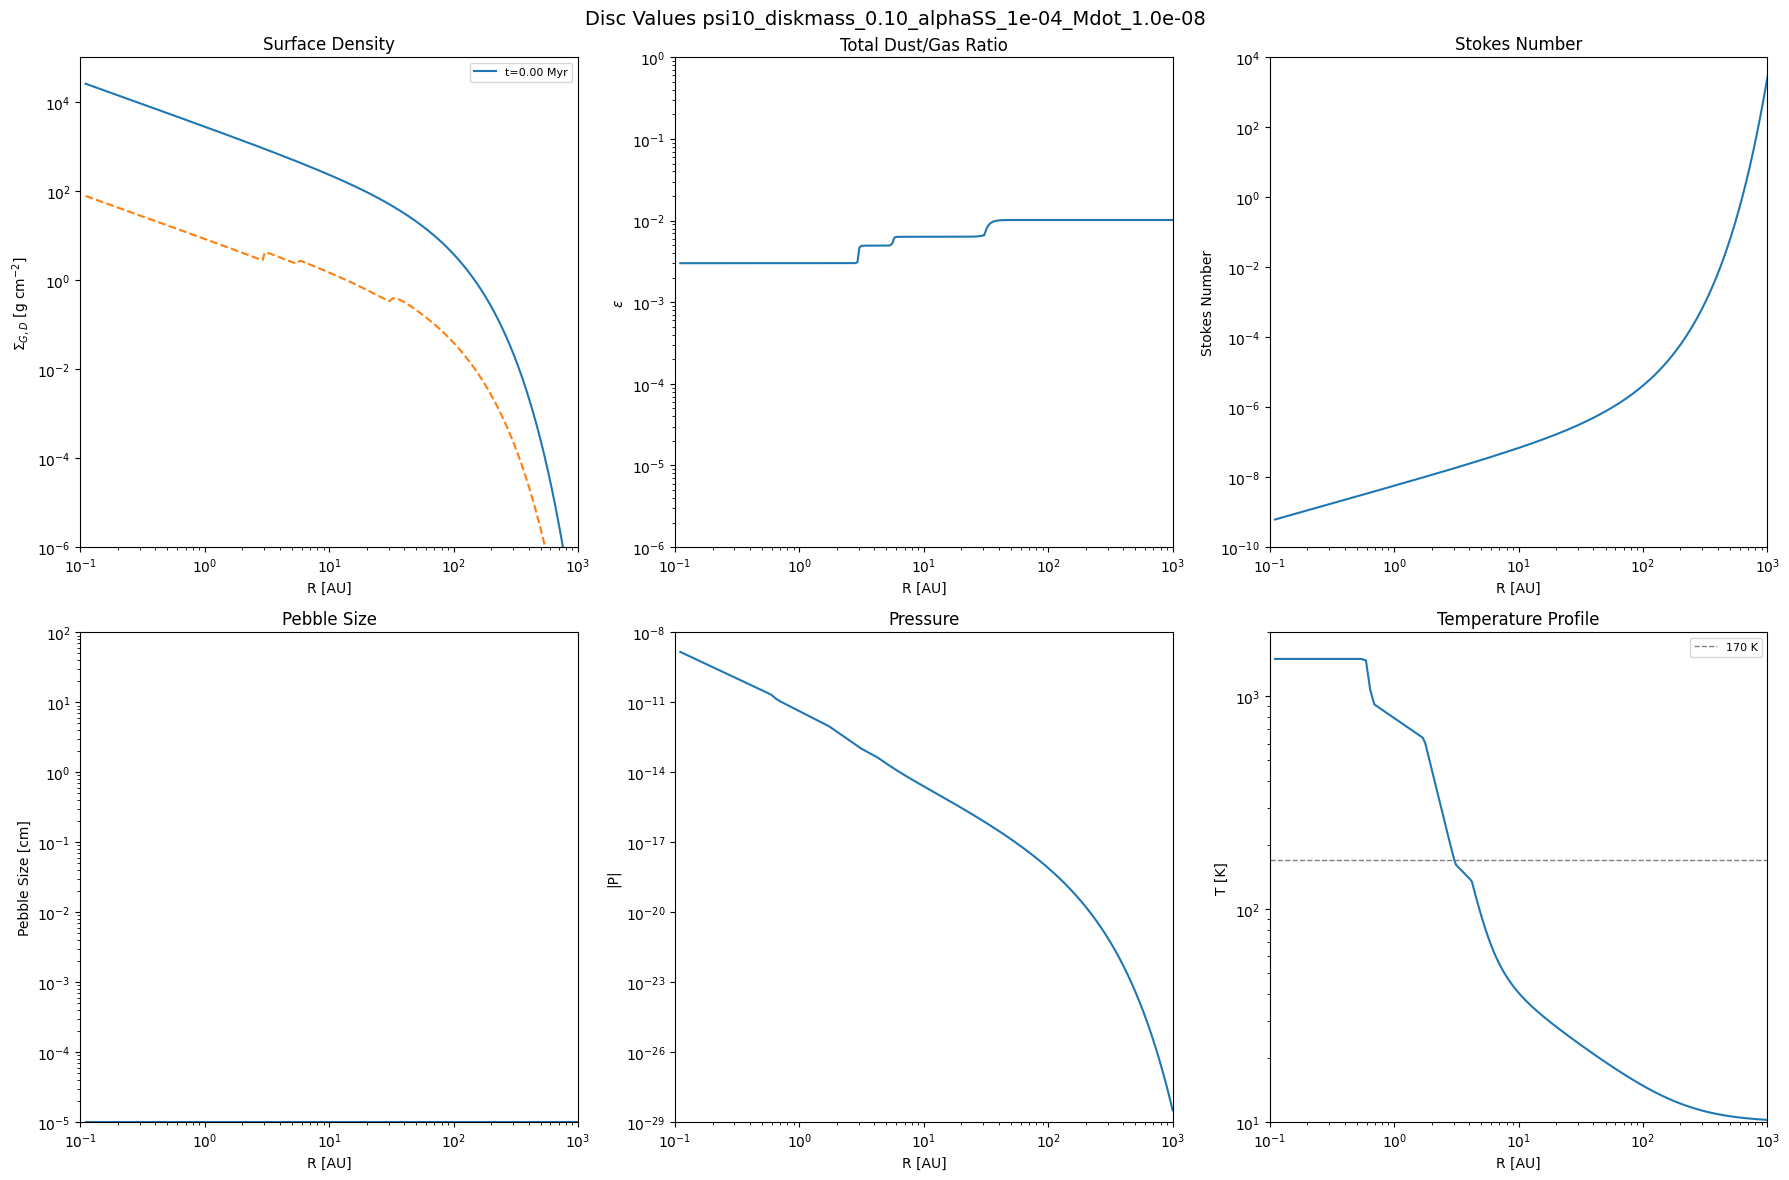

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/disc_values_1.png


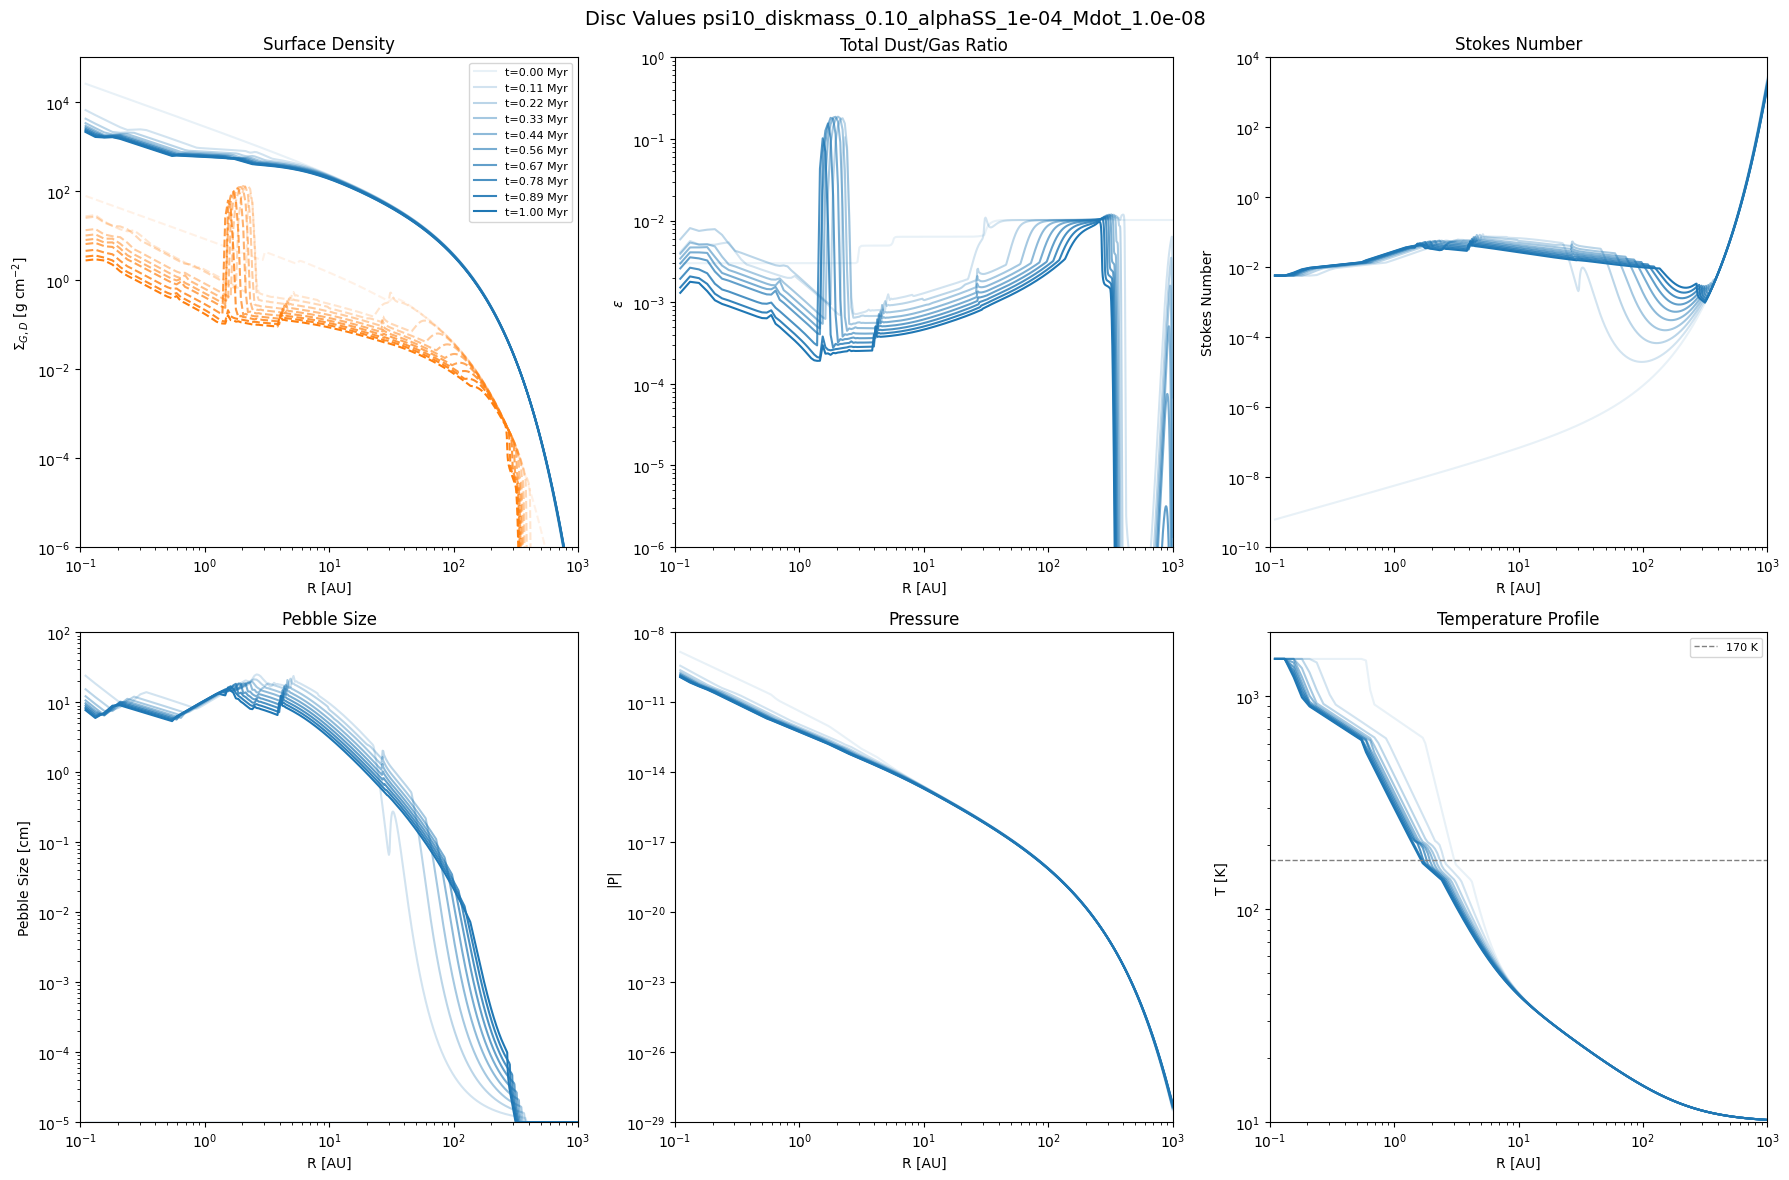

In [29]:
plot_disc_initial_values()
plot_disc_values()

## 12.1 Surface density zoom near 15 AU
Baseline (no dead zone) gas/dust surface density zoomed around 15 AU, for comparison
with a run that has a dead zone at 15 AU. A dead zone edge should show up here as a gas
pile-up just outside 15 AU and a dust trap (peak in $\Sigma_D$) at the pressure maximum.

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/Sigma_zoom_15AU.png


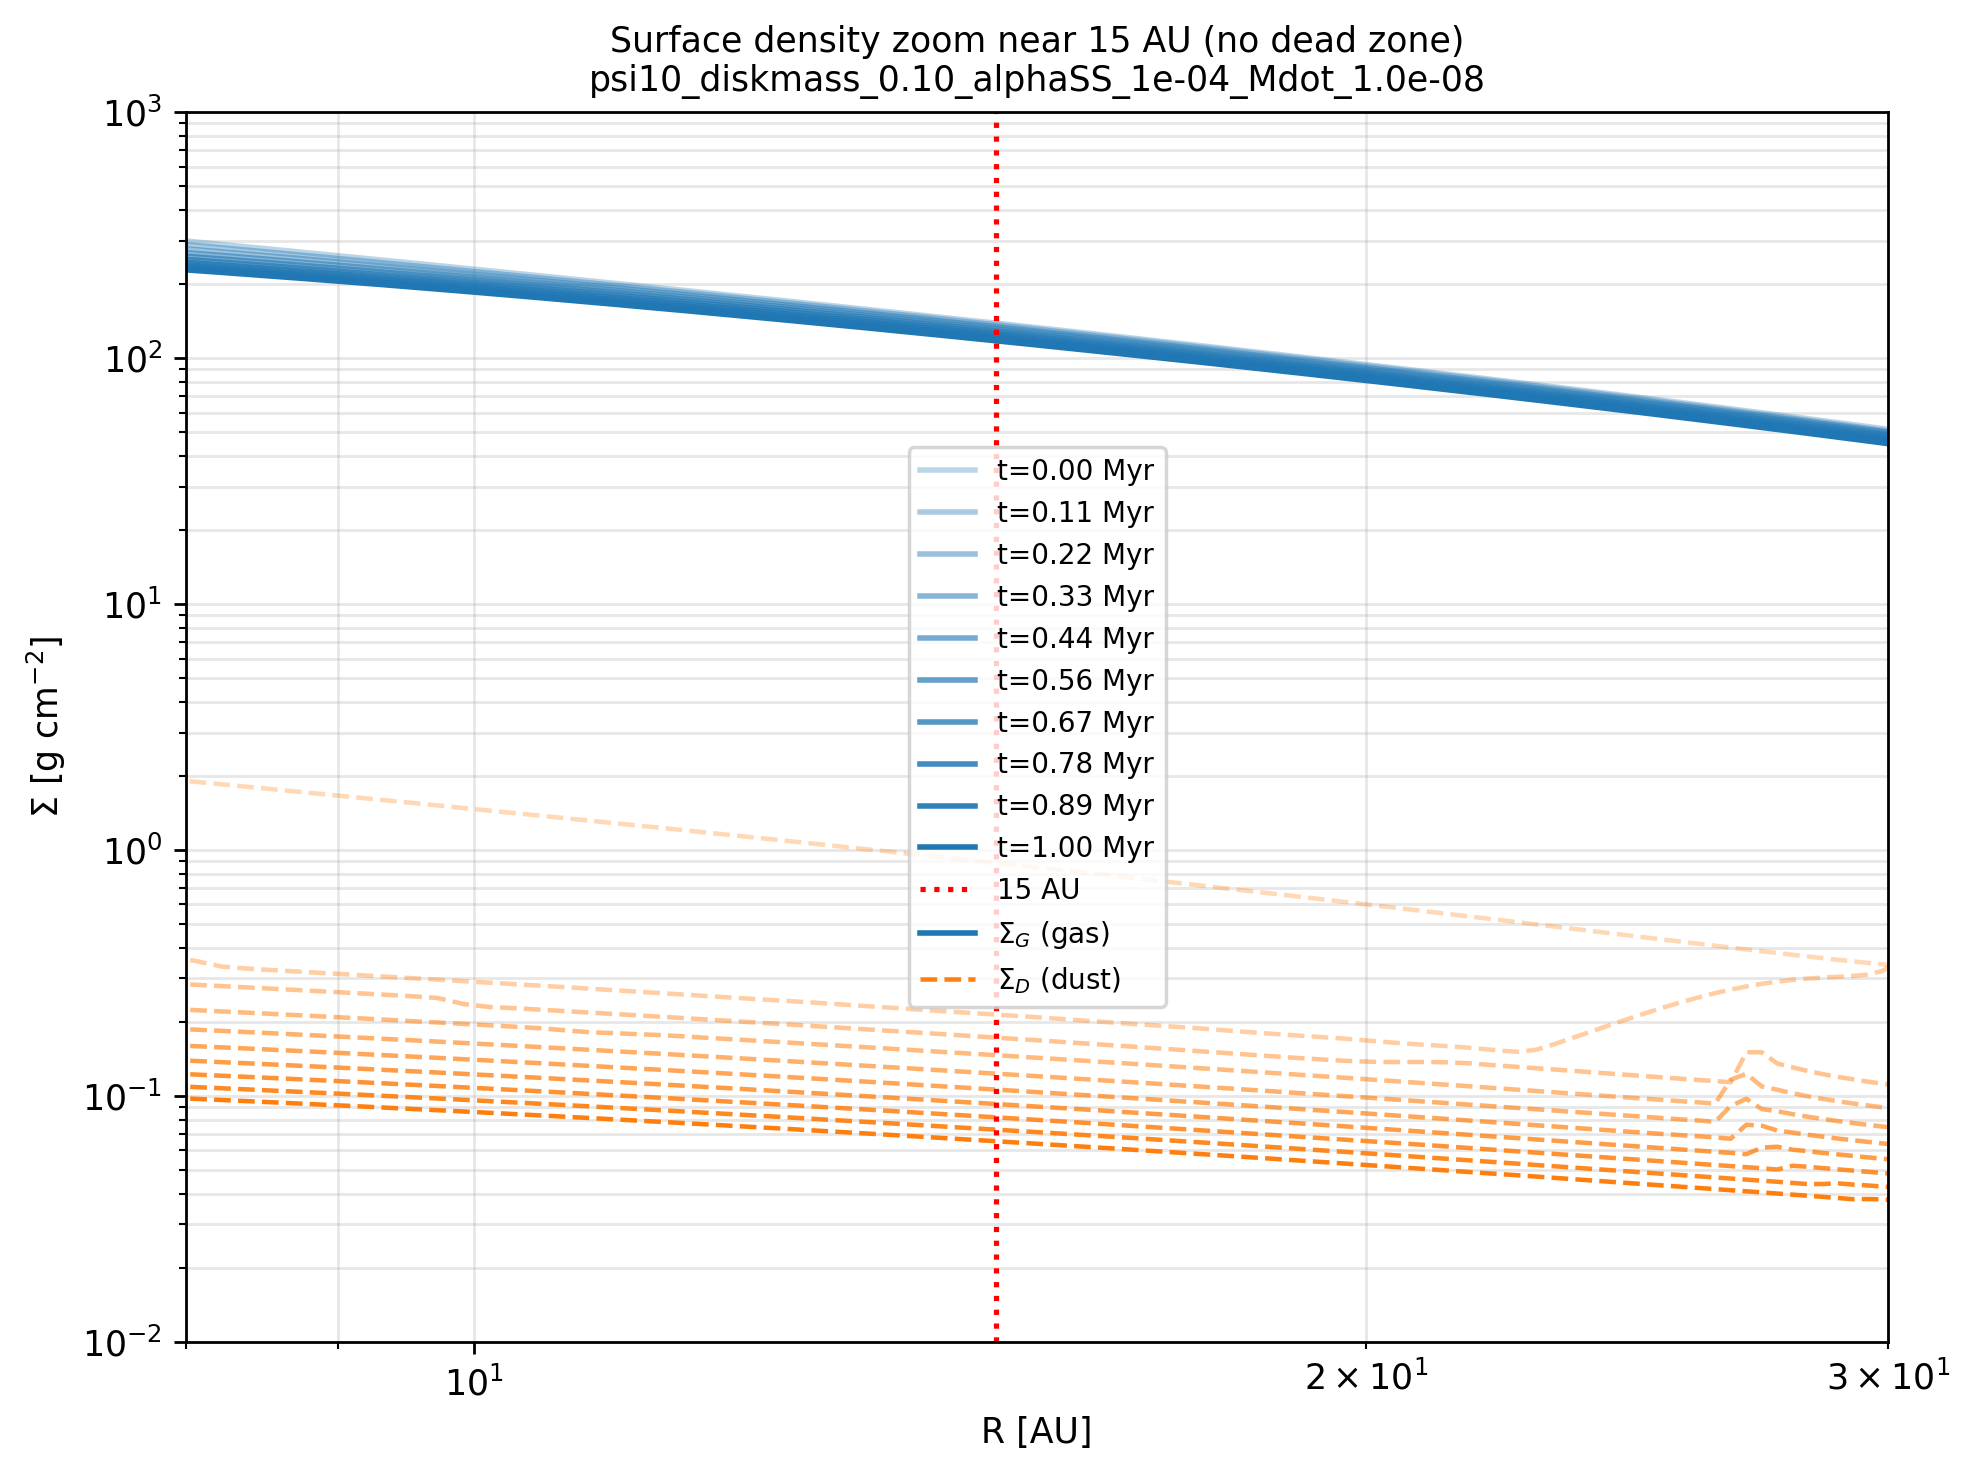

In [30]:
# Zoom on the surface density profile around 15 AU (compare against a dead zone at 15 AU)
R_dz_compare = 15.0   # AU
R_lo, R_hi   = 8.0, 30.0

fig, ax = plt.subplots(figsize=(8, 6), dpi=250)

n_snaps = len(history['t_yr'])
alphas  = np.linspace(0.3, 1.0, max(n_snaps, 1))

for i in range(n_snaps):
    ax.loglog(disc.R, history['Sigma_G'][i], color='C0', ls='solid',
              alpha=alphas[i], lw=1.6, label=rf"t={history['t_yr'][i]/1e6:.2f} Myr")
    ax.loglog(disc.R, history['Sigma_D'][i], color='C1', ls='dashed',
              alpha=alphas[i], lw=1.3)

ax.axvline(R_dz_compare, ls=':', color='red', lw=1.5, label=f'{R_dz_compare:.0f} AU')

# y-range from whatever falls inside the zoom window
mask = (disc.R >= R_lo) & (disc.R <= R_hi)
Sg_win = np.array(history['Sigma_G'])[:, mask]
Sd_win = np.array(history['Sigma_D'])[:, mask]
ymin = min(Sg_win[Sg_win > 0].min(), Sd_win[Sd_win > 0].min())
ymax = max(Sg_win.max(), Sd_win.max())

ax.set_xlim(R_lo, R_hi)
ax.set_ylim(10**np.floor(np.log10(ymin)), 10**np.ceil(np.log10(ymax)))
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\Sigma$ [g cm$^{-2}$]')
ax.set_title('Surface density zoom near 15 AU (no dead zone)\n' + subfolder, fontsize=10)

# legend: time entries + a gas/dust style key
handles, labels = ax.get_legend_handles_labels()
from matplotlib.lines import Line2D
handles += [Line2D([0], [0], color='C0', ls='solid', lw=1.6, label=r'$\Sigma_G$ (gas)'),
            Line2D([0], [0], color='C1', ls='dashed', lw=1.3, label=r'$\Sigma_D$ (dust)')]
ax.legend(handles=handles, fontsize=8, loc='best')

ax.grid(True, which='both', alpha=0.3)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
savefig('Sigma_zoom_15AU.png', subfolder)
plt.show()

# 13. Torque Maps

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/torque_maps.png


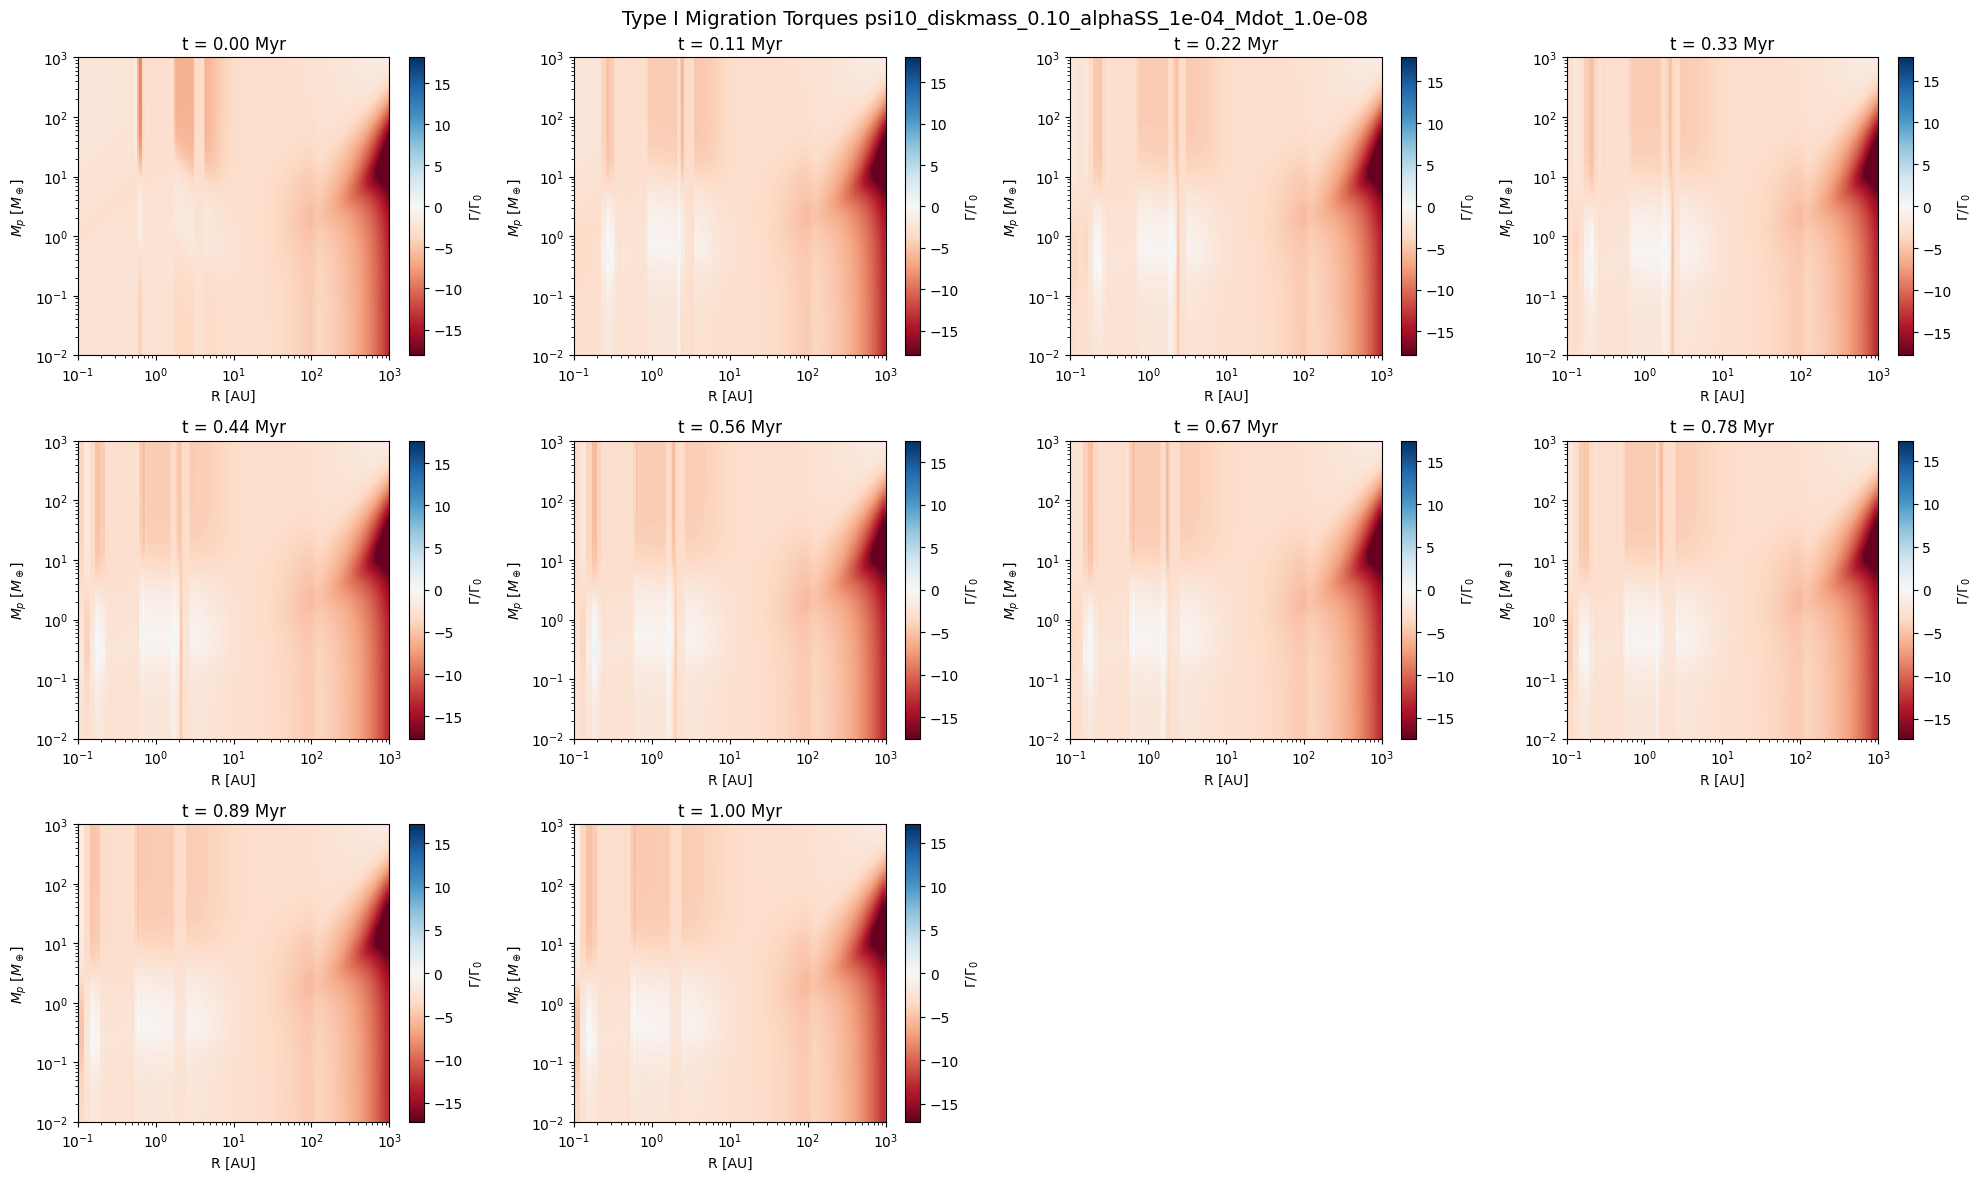

In [31]:

n_maps = len(torque_maps['maps'])
ncols = 4
nrows = int(np.ceil(n_maps / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = np.atleast_2d(axes)

for idx in range(n_maps):
    ax = axes[idx // ncols, idx % ncols]
    T_map = torque_maps['maps'][idx]
    t_label = torque_maps['t_yr'][idx]

    # Symmetric colour scale around zero
    vmax = np.percentile(np.abs(T_map), 98) #drop top 2% of values to get less washed out look
    vmin = -vmax

    im = ax.pcolormesh(
        radius_array, mass_array, T_map,
        cmap='RdBu',        # red = inward (negative), blue = outward (positive)
        vmin=vmin, vmax=vmax,
        shading='auto'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R [AU]')
    ax.set_ylabel(r'$M_p$ [$M_\oplus$]')
    ax.set_title(f't = {t_label/1e6:.2f} Myr')
    ax.set_xlim(R_in, R_out)
    fig.colorbar(im, ax=ax, label=r'$\Gamma / \Gamma_0$')

# Hide unused axes
for idx in range(n_maps, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.suptitle('Type I Migration Torques '+subfolder, fontsize=14)
plt.tight_layout()
savefig('torque_maps.png', subfolder)
plt.show()


# 14. Accretion Rate Plot

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/Mdot_star.png


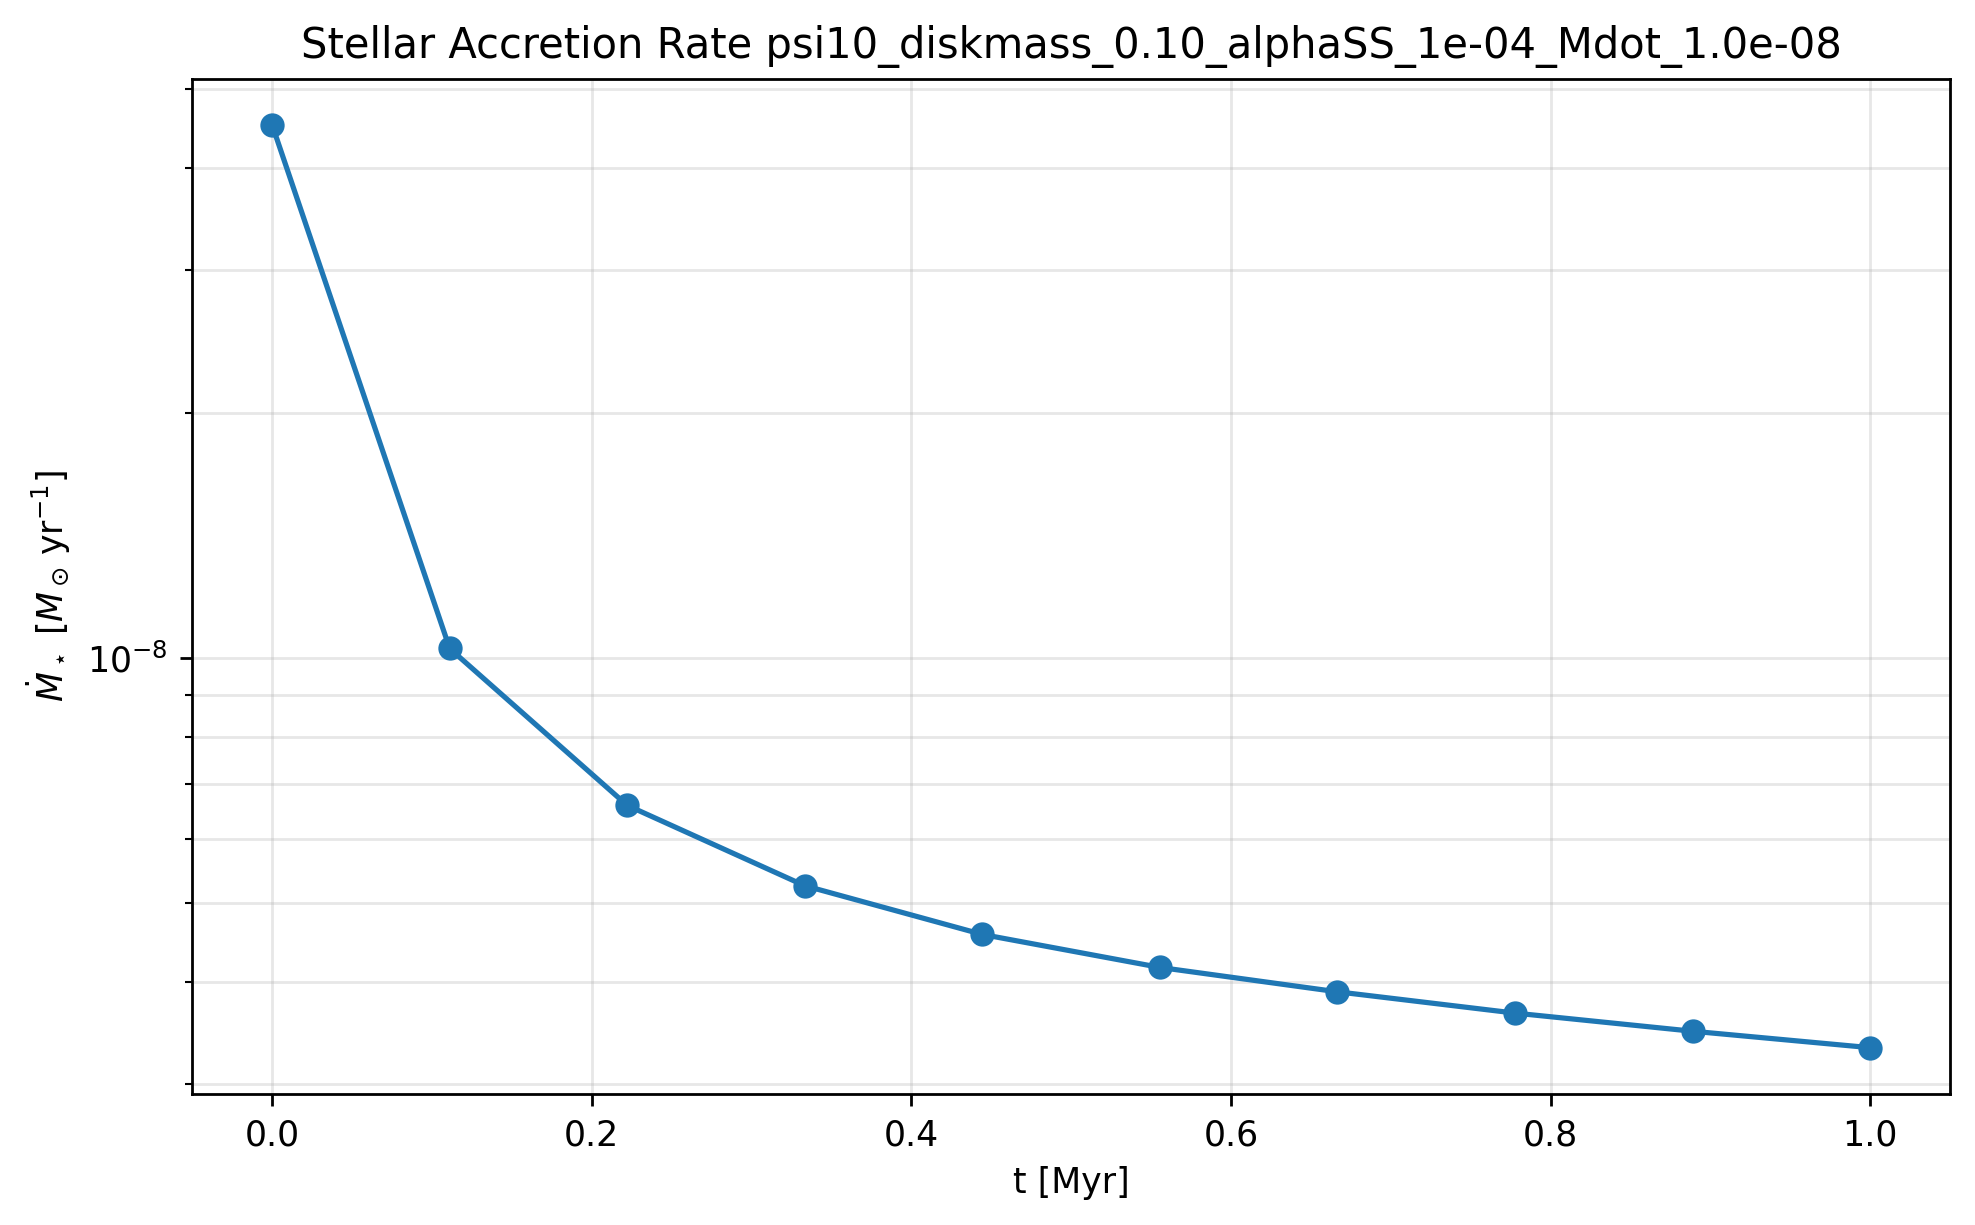

In [32]:
fig, ax = plt.subplots(figsize=(8, 5), dpi = 250)

ax.semilogy(np.array(history['t_yr']) / 1e6, np.array(history['Mdot_star']), 'o-', color='C0', lw=1.5)
ax.set_xlabel('t [Myr]')
ax.set_ylabel(r'$\dot{M}_\star$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Stellar Accretion Rate '+subfolder)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()

savefig('Mdot_star.png', subfolder) 
plt.show()

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/Mdot_r.png


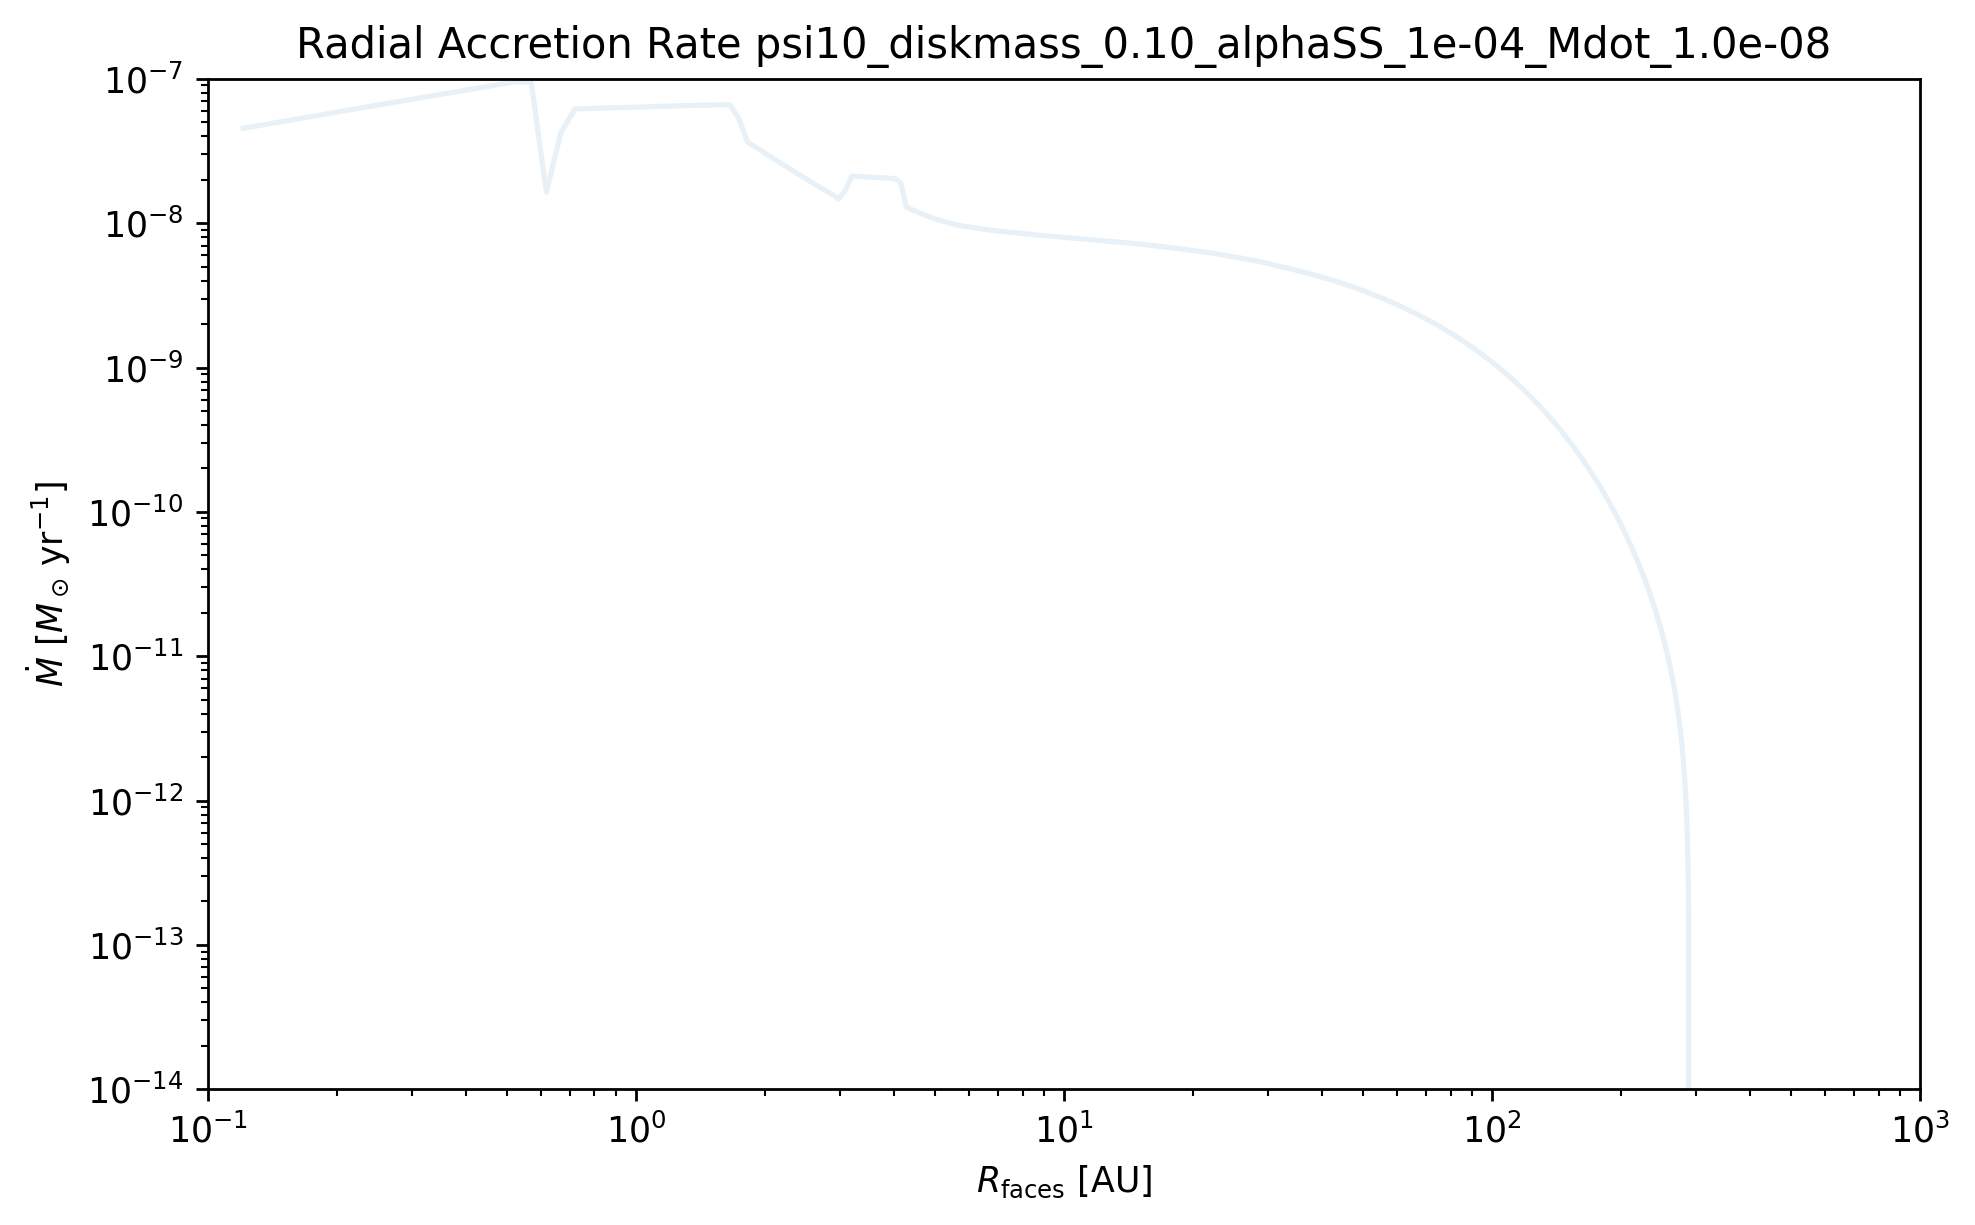

In [33]:
fig, ax = plt.subplots(figsize=(8, 5), dpi = 250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

# Remove this line: ax = axes[1, 0]

for i, line in enumerate(history['Mdot_r']):
    ax.loglog(history['R_faces'][i], history['Mdot_r'][i], linestyle='solid', color='C0', alpha=alphas[i],
                label=rf"t={history['t_yr'][i]/1e6:.2f} Myr", lw=1.5)
    if i > -1: 
        break

ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate '+subfolder)
ax.set_xlim(R_in, R_out)
# Filter for finite AND positive values (needed for log scale)
Mdot_r_flat = np.array(history['Mdot_r']).flatten()
Mdot_r_valid = Mdot_r_flat[(np.isfinite(Mdot_r_flat)) & (Mdot_r_flat > 0)]
if len(Mdot_r_valid) > 0:
    ax.set_ylim(10**(np.floor(np.log10(np.min(Mdot_r_valid)))), 10**(np.ceil(np.log10(np.max(Mdot_r_valid)))))
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
#ax.axvline(R_dz.value, ls = ':', color = 'red')

savefig('Mdot_r.png', subfolder)
plt.show()

In [34]:
history['Rc']

[]

In [35]:
# Diagnostic: Check Mdot_r values at different radii
print("=== Mdot_r Diagnostic ===")
print(f"\nFinal snapshot (t = {history['t_yr'][-1]/1e6:.2f} Myr):")
print(f"Mdot at star: {history['Mdot_star'][-1]:.3e} Msun/yr")

# Check values at different radii
R_faces_final = history['R_faces'][-1]
Mdot_r_final = history['Mdot_r'][-1]

# Find specific radii
idx_10 = np.argmin(np.abs(R_faces_final - 10))
idx_20 = np.argmin(np.abs(R_faces_final - 20))  # Dead zone boundary
idx_50 = np.argmin(np.abs(R_faces_final - 50))
idx_100 = np.argmin(np.abs(R_faces_final - 100))

print(f"\nMdot(R=~{R_faces_final[idx_10]:.1f} AU) = {Mdot_r_final[idx_10]:.3e} Msun/yr")
print(f"Mdot(R=~{R_faces_final[idx_20]:.1f} AU) = {Mdot_r_final[idx_20]:.3e} Msun/yr  <- Dead zone")
print(f"Mdot(R=~{R_faces_final[idx_50]:.1f} AU) = {Mdot_r_final[idx_50]:.3e} Msun/yr")
print(f"Mdot(R=~{R_faces_final[idx_100]:.1f} AU) = {Mdot_r_final[idx_100]:.3e} Msun/yr")

# Check for negative values (outward flow)
n_negative = np.sum(Mdot_r_final < 0)
print(f"\n{n_negative} radii have negative Mdot (outward flow)")
if n_negative > 0:
    neg_mask = Mdot_r_final < 0
    print(f"Negative Mdot range: R = {R_faces_final[neg_mask].min():.1f} to {R_faces_final[neg_mask].max():.1f} AU")
    print(f"Most negative: {Mdot_r_final[neg_mask].min():.3e} Msun/yr at R = {R_faces_final[np.argmin(Mdot_r_final)]:.1f} AU")

# Check Sigma at outer edge
print(f"\nSurface density at R=100 AU: {disc.Sigma[np.argmin(np.abs(disc.R - 100))]:.3e} g/cm^2")
print(f"Disc outer radius (Rout): {history['Rout'][-1]:.1f} AU")
#print(f"Disc characteristic radius (Rc): {history['Rc'][-1]:.1f} AU")

=== Mdot_r Diagnostic ===

Final snapshot (t = 1.00 Myr):
Mdot at star: 3.324e-09 Msun/yr

Mdot(R=~10.0 AU) = 6.663e-09 Msun/yr
Mdot(R=~20.1 AU) = 5.616e-09 Msun/yr  <- Dead zone
Mdot(R=~50.1 AU) = 3.033e-09 Msun/yr
Mdot(R=~99.8 AU) = 9.996e-10 Msun/yr

459 radii have negative Mdot (outward flow)
Negative Mdot range: R = 297.7 to 998.0 AU
Most negative: -2.832e-12 Msun/yr at R = 350.6 AU

Surface density at R=100 AU: 3.422e+00 g/cm^2
Disc outer radius (Rout): 659.2 AU


Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/Mdot_r_absolute.png


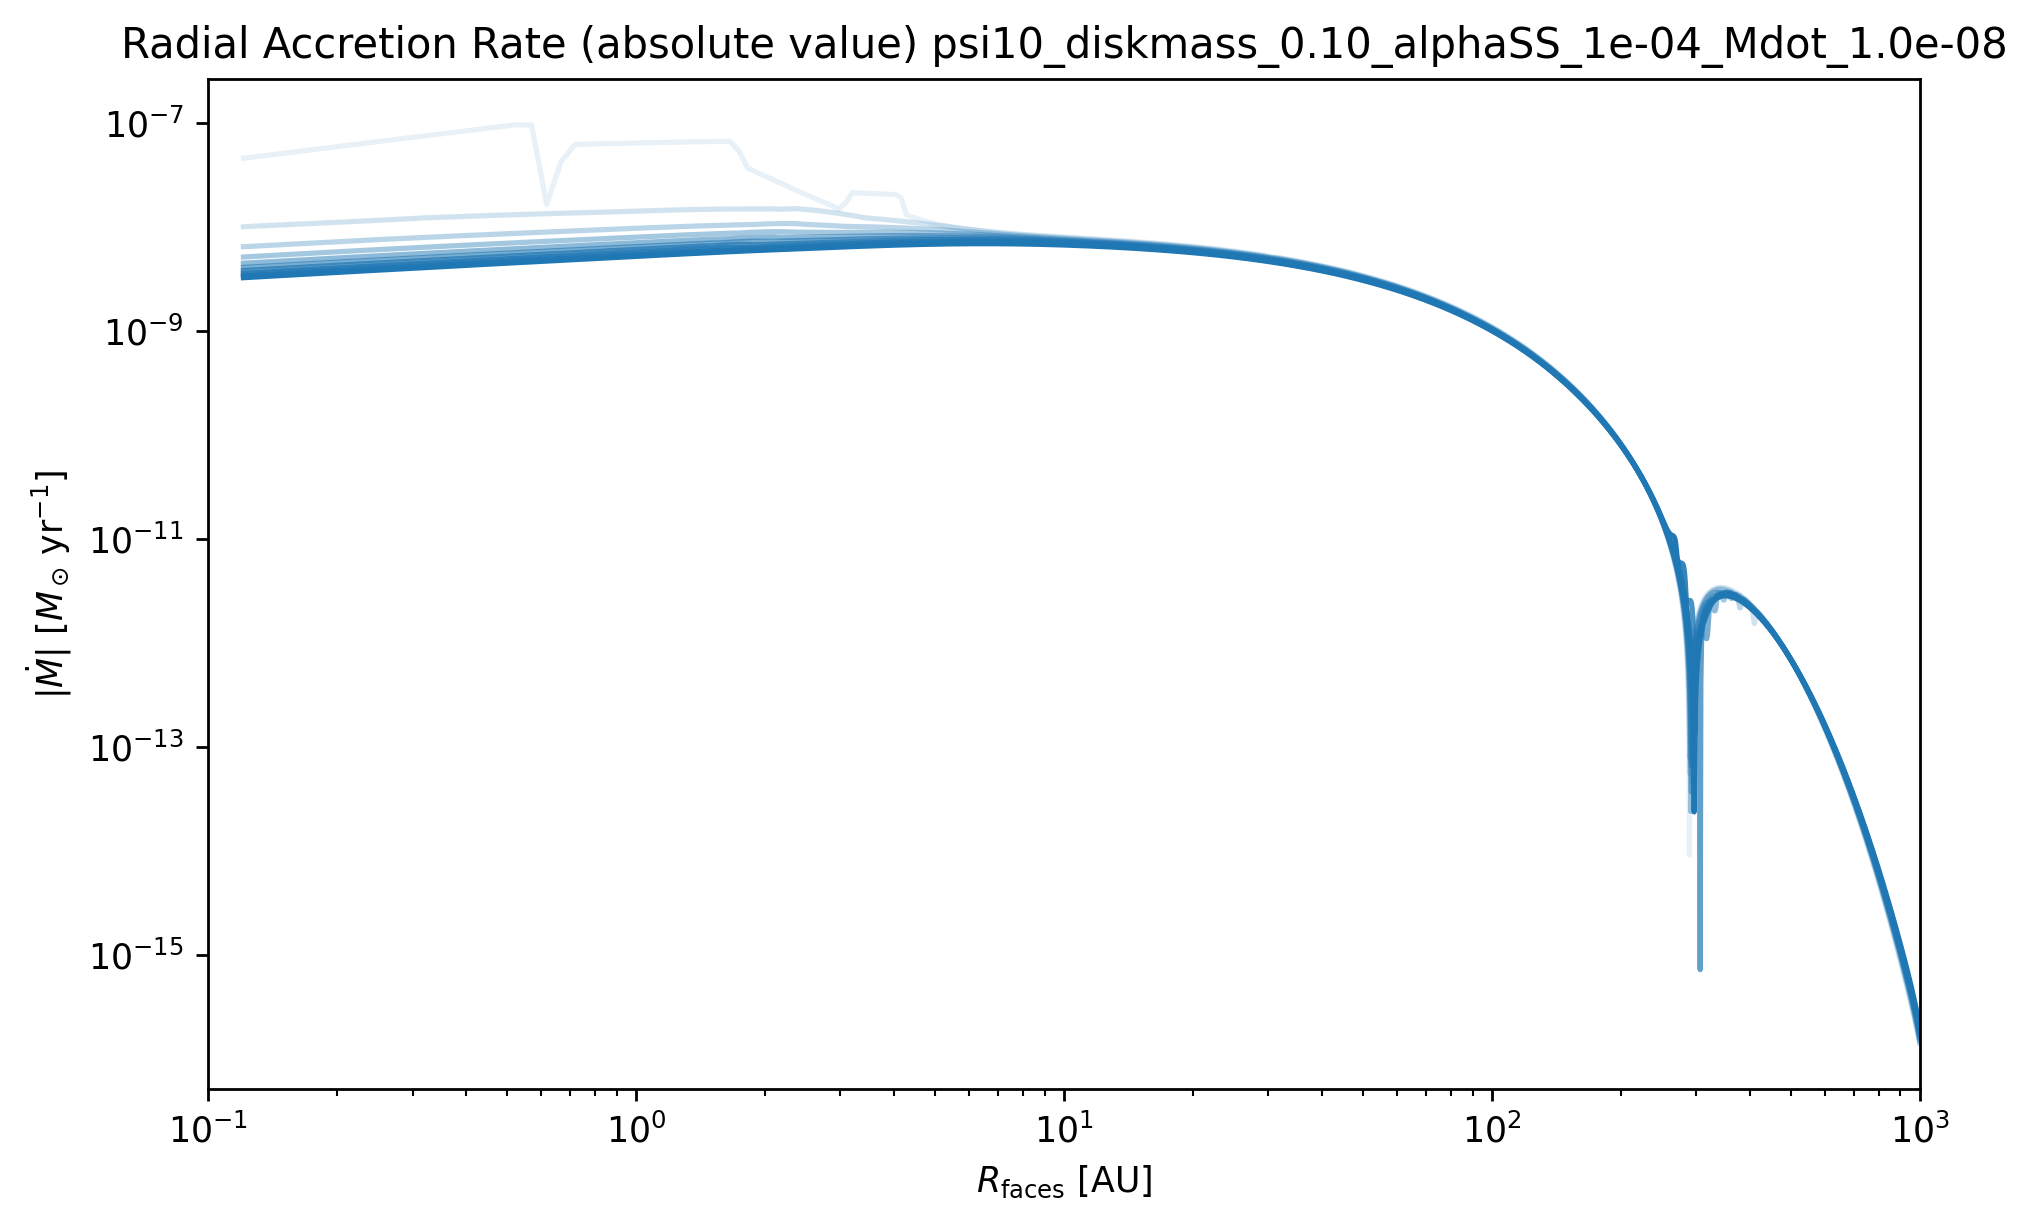

In [36]:
# Better visualization showing both inward (positive) and outward (negative) flow
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

for i in range(len(history['Mdot_r'])):
    R = history['R_faces'][i]
    Mdot = history['Mdot_r'][i]
    
    # Plot absolute value on log scale, with color indicating direction #TODO: color indicating direction?
    ax.loglog(R, np.abs(Mdot), linestyle='solid', color='C0', alpha=alphas[i], lw=1.5)

ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$|\dot{M}|$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate (absolute value) '+subfolder)
ax.set_xlim(R_in, R_out)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
#ax.axvline(R_dz.value, ls = ':', color = 'red')

savefig('Mdot_r_absolute.png', subfolder)
plt.show()

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/Mdot_r_signed.png


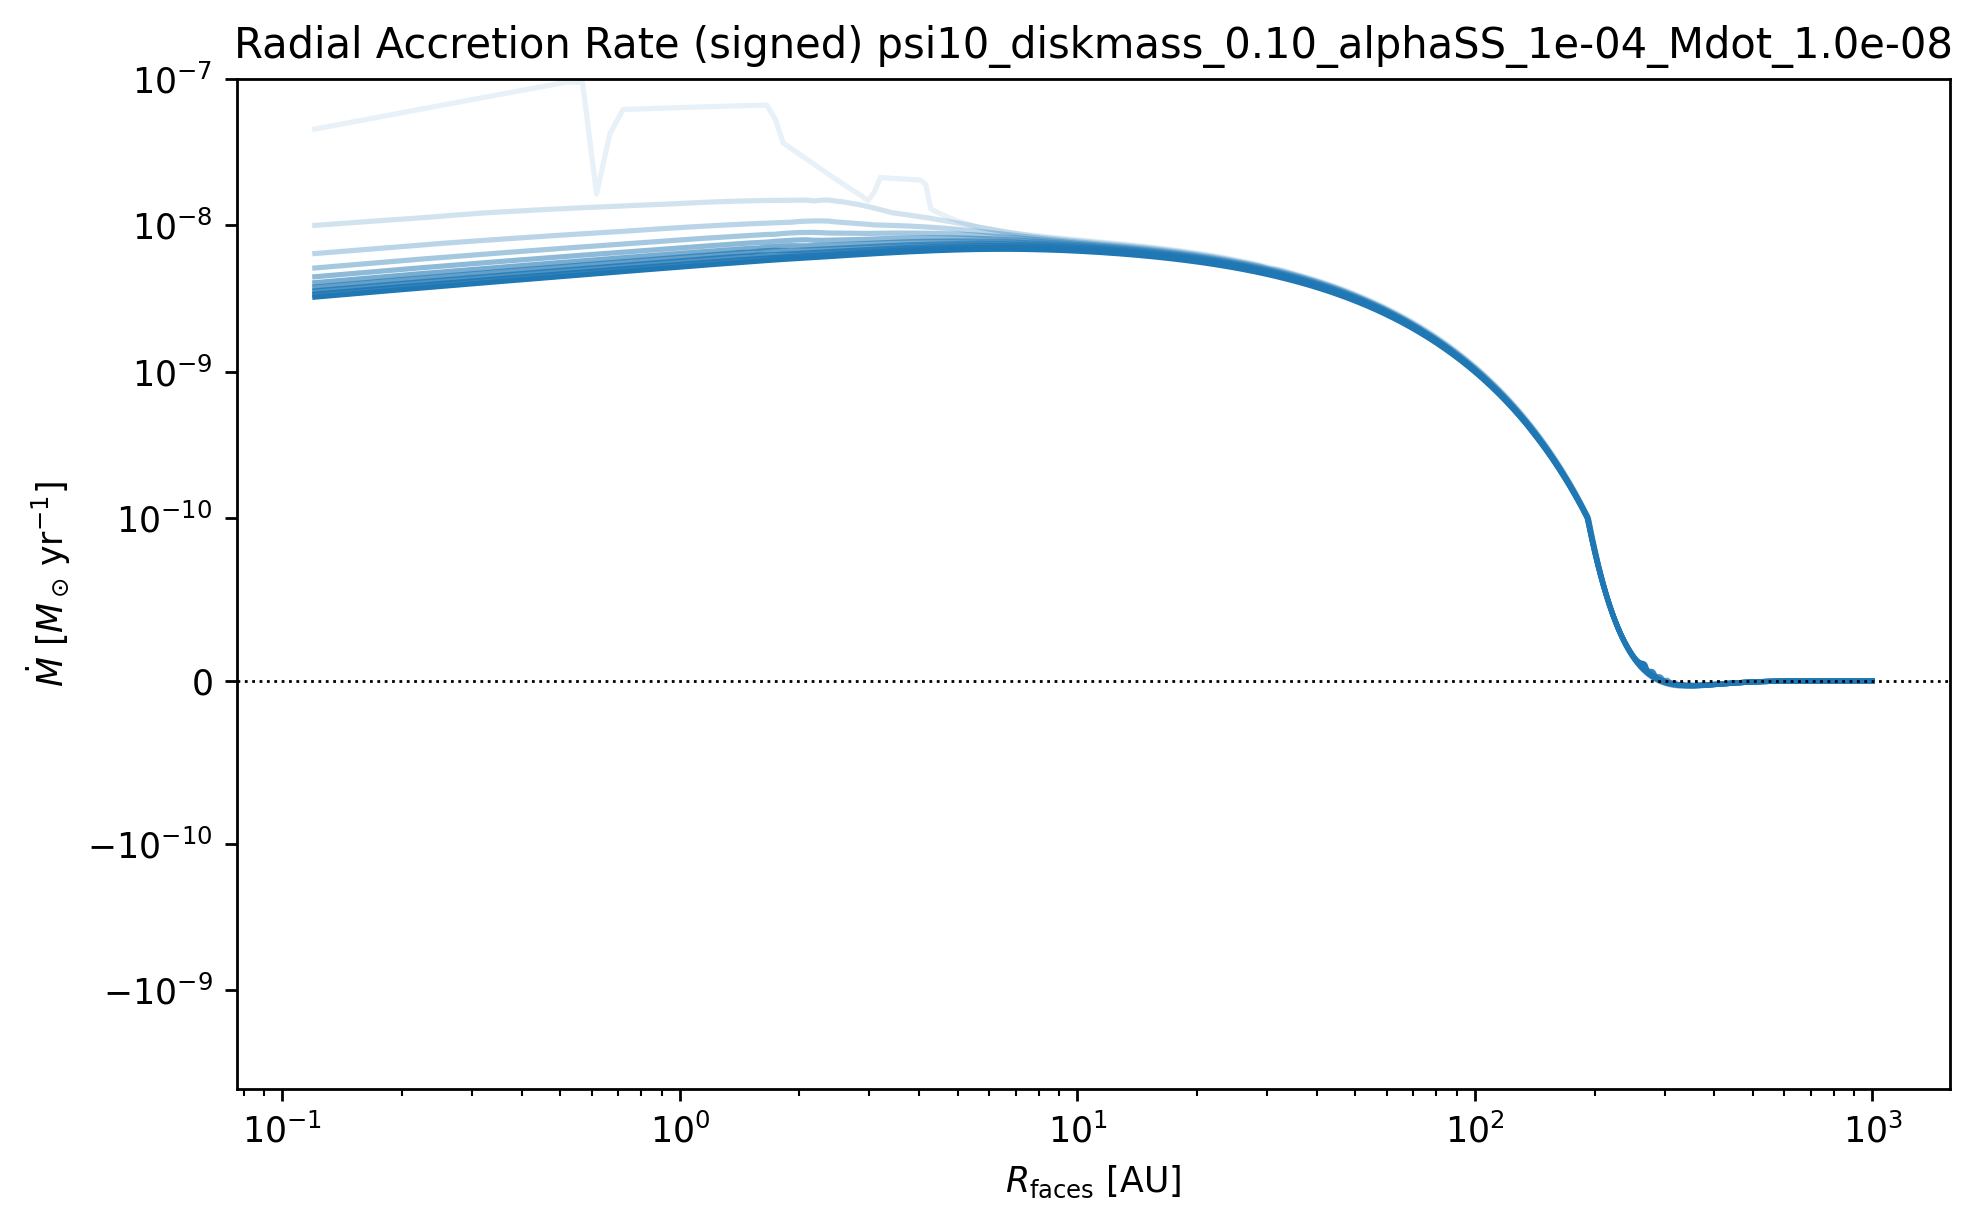

In [37]:
# Alternative: signed plot with symlog scale (shows both positive and negative)
fig, ax = plt.subplots(figsize=(8, 5), dpi=250)

n_snaps = len(history['t_yr'])
alphas = np.linspace(0.1, 1.0, max(n_snaps, 1))

for i in range(len(history['Mdot_r'])):
    ax.semilogx(history['R_faces'][i], history['Mdot_r'][i], 
                linestyle='solid', color='C0', alpha=alphas[i], lw=1.5)

ax.axhline(0, color='k', linestyle=':', lw=0.8, label='Zero (transition)')
ax.set_xlabel(r'$R_{\rm faces}$ [AU]')
ax.set_ylabel(r'$\dot{M}$ [$M_\odot\,\mathrm{yr}^{-1}$]')
ax.set_title('Radial Accretion Rate (signed) '+subfolder)
#ax.set_xlim(1, 10)
ax.set_yscale('symlog', linthresh=1e-10)  # Symmetric log scale
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=2)
plt.tight_layout()
#ax.axvline(R_dz.value, ls = ':', color = 'red')

savefig('Mdot_r_signed.png', subfolder)
plt.show()

# 16. Planet Growth Tracks

In [38]:
history['planets_R']

[array([], dtype=float32),
 array([ 0.99826701,  1.49621742,  1.98968023,  2.92711804,  3.91994478,
         4.8719175 ,  5.68756376,  6.62863521,  8.13872778,  9.64542111,
        12.19019644, 14.74720902, 19.97653513, 24.98283784, 29.98432109]),
 array([ 0.9869545 ,  1.38594884,  1.55743984,  2.10491293,  3.12051959,
         3.98447934,  4.71199725,  5.6128931 ,  6.99896452,  8.39350079,
        10.72973452, 13.06719991, 18.57809107, 24.35570788, 27.82556957]),
 array([ 0.72822827,  0.56244301,  0.29959436,  1.20030128,  2.39059692,
         3.36306027,  4.16473796,  5.12505653,  6.5638796 ,  7.98541556,
        10.34003377, 12.68254095, 16.5991863 , 21.69232968, 26.62960609]),
 array([ 0.11014193,  0.11012565,  0.11013379,  0.11014157,  1.60867719,
         2.6949609 ,  3.59591668,  4.62691389,  6.12429332,  7.57507278,
         9.94978595, 12.29799593, 16.21451589, 20.00883045, 26.23496956]),
 array([ 0.11014193,  0.11012565,  0.11013379,  0.11014157,  0.59936719,
         1.99787

In [39]:
history['planets_Mcore']

[array([], dtype=float32),
 array([0.01251598, 0.01941177, 0.04304115, 0.18611683, 0.21075072,
        0.26057295, 0.75776898, 0.7648988 , 0.6006943 , 0.54376078,
        0.43435477, 0.33703526, 0.01764662, 0.01055952, 0.01002233]),
 array([0.08127865, 0.4182376 , 1.44102411, 8.99868525, 5.96440025,
        6.5488049 , 8.19328618, 7.89175748, 7.65906998, 7.2217158 ,
        7.07396446, 5.51405519, 1.32550432, 0.52447632, 2.64882623]),
 array([ 0.54505648,  1.83411389,  4.37771504,  8.99868525,  7.73566903,
         7.40309874,  8.19328618,  7.89175748,  7.65906998,  7.2217158 ,
         7.63997389,  8.20921127,  4.84424393,  2.17822646, 10.13123105]),
 array([ 1.37284506,  2.76739166,  4.37771504,  8.99868525,  7.73566903,
         7.40309874,  8.19328618,  7.89175748,  7.65906998,  7.2217158 ,
         7.63997389,  8.20921127,  8.82571045,  5.09518187, 12.12019642]),
 array([ 1.37284506,  2.76739166,  4.37771504,  8.99868525,  7.73566903,
         7.40309874,  8.19328618,  7.89175748,

In [40]:
history['planets_Menv']

[array([], dtype=float32),
 array([2.82056292e-04, 1.04801140e-03, 3.67458268e-03, 1.96317772e-02,
        2.24042685e-02, 2.80417220e-02, 8.63965165e-02, 8.75988872e-02,
        6.78473285e-02, 6.11530164e-02, 4.82725845e-02, 3.69555678e-02,
        8.61813113e-04, 8.63148933e-05, 3.00173727e-05]),
 array([0.00793045, 0.04593478, 0.18118669, 4.27088018, 1.55134403,
        1.94812093, 4.65263591, 4.56722757, 4.52965613, 3.96634129,
        2.72314144, 1.8378069 , 0.195186  , 0.06140696, 0.57609968]),
 array([ 0.0611382 ,  0.25222246,  0.89440527,  7.40627456,  5.22177455,
         5.47498092,  8.01875126,  7.88366656, 28.00271716,  7.20924166,
         7.48329545,  7.89232216,  1.78604595,  0.47594838,  6.74214259]),
 array([1.66070089e-01, 4.10407759e-01, 9.70938092e-01, 8.61196520e+00,
        7.14015066e+00, 7.36058870e+00, 2.41985341e+02, 2.57229012e+02,
        2.70785712e+02, 2.39703010e+02, 2.17251843e+02, 2.02119595e+02,
        7.90200208e+00, 2.32102553e+00, 1.16551004e+02])

Saved: /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/planet_MR_tracks.png


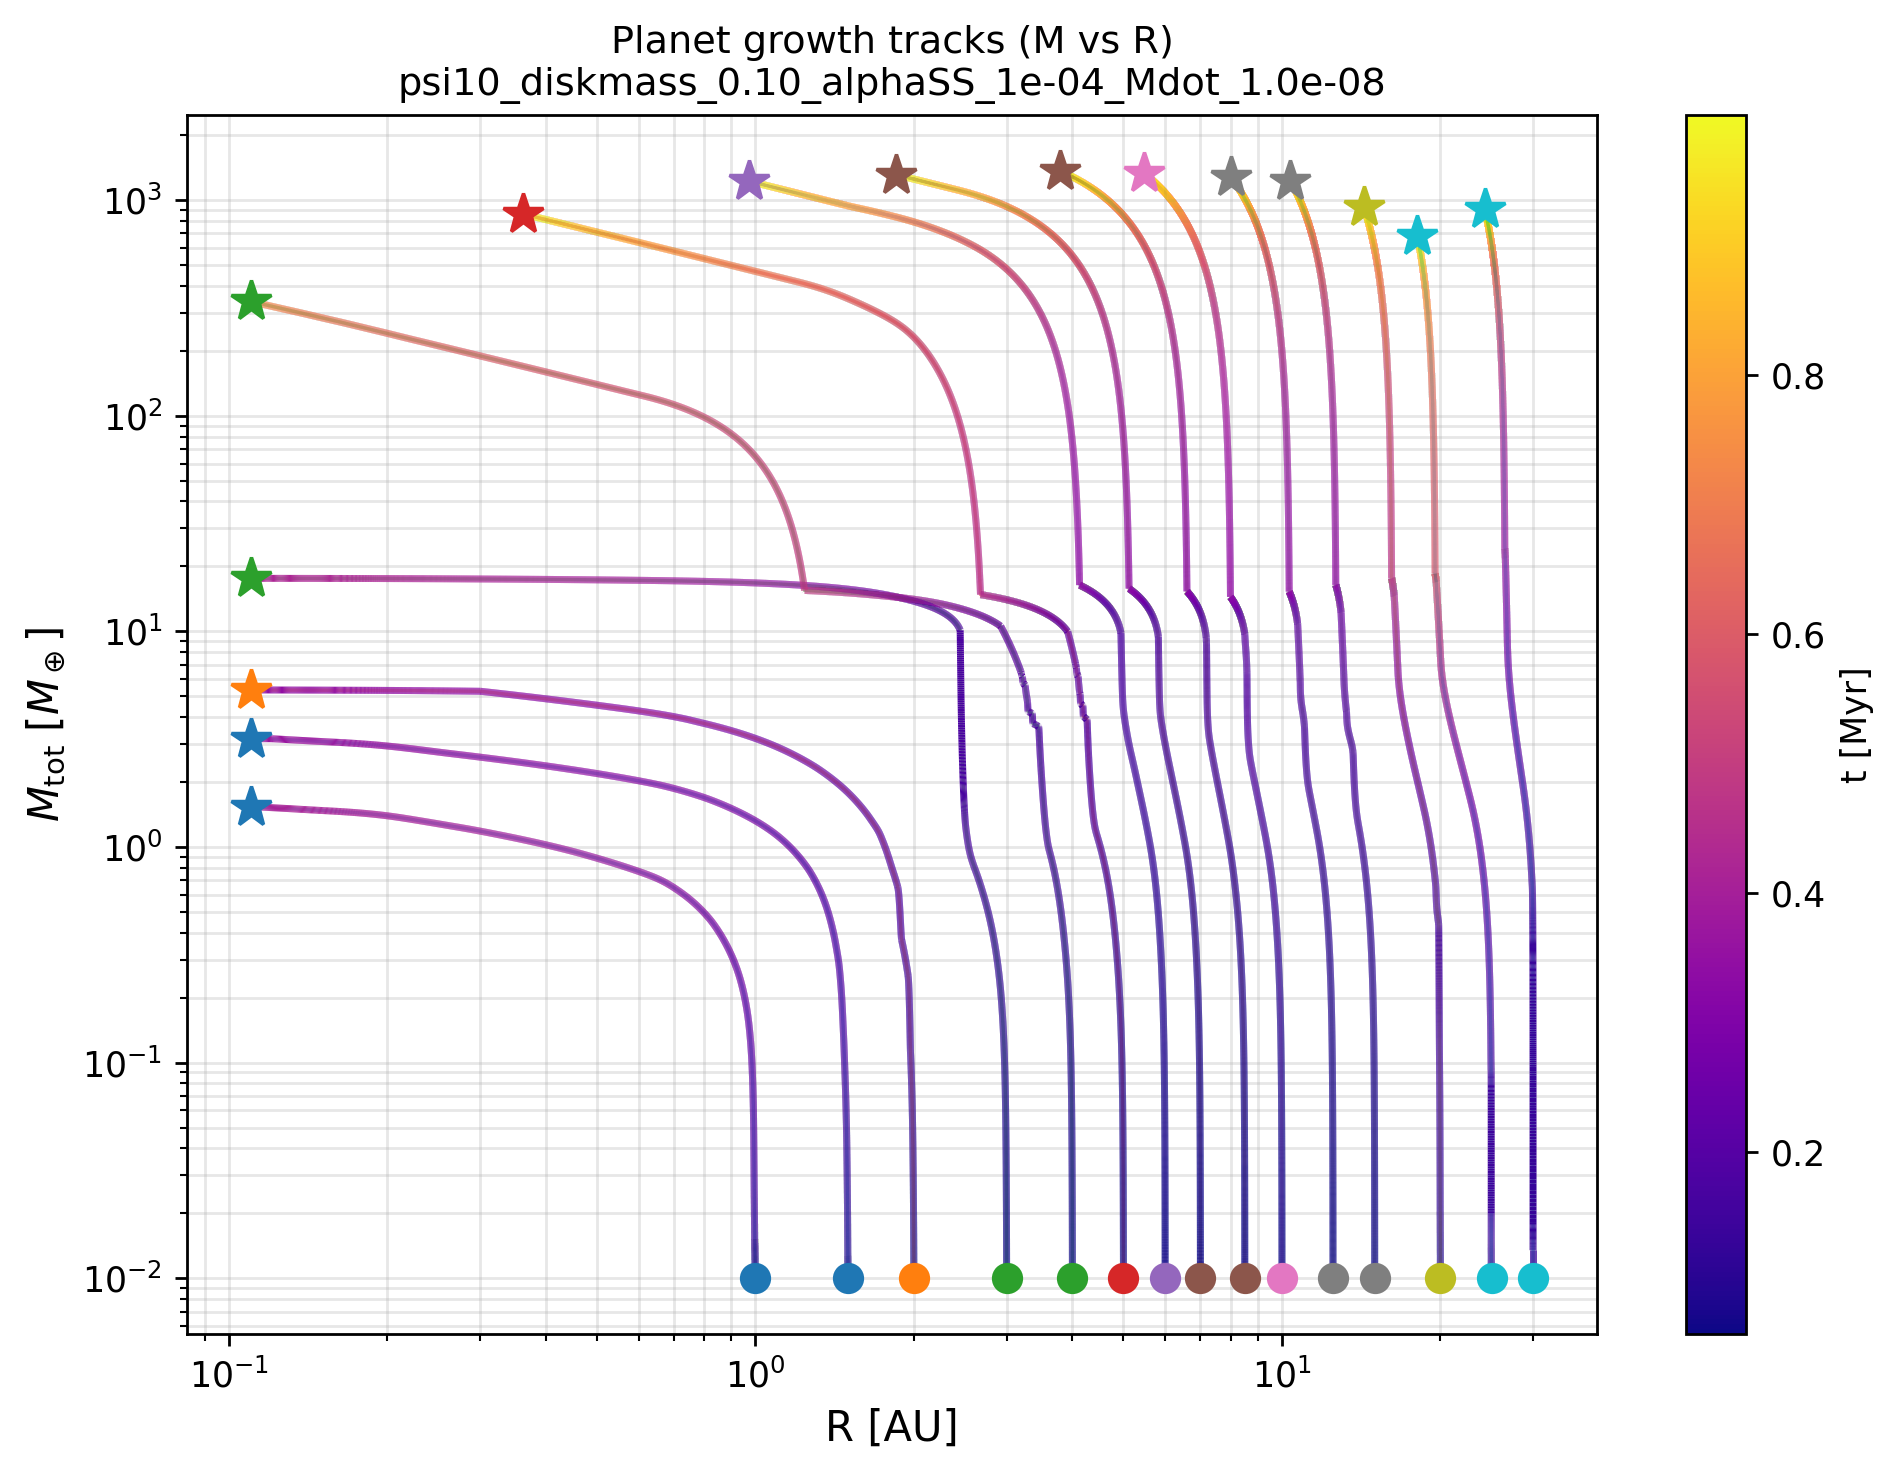

In [41]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6), dpi=250)

# Use the planet data logged every 5 steps (planet_log)
if len(planet_log['R']) == 0:
    print("No planet data logged in planet_log.")
else:
    t_log = np.array(planet_log['t_yr']) / 1e6  # Myr
    t_seed = implant_time_yr / 1e6              # implantation time (seed point)
    n_planets = len(planet_log['R'][0])
    colors = plt.cm.tab10(np.linspace(0, 1, max(n_planets, 1)))

    # Prepend the implantation time so the colour scale starts at the seed
    t_snaps = np.concatenate([[t_seed], t_log])
    norm = Normalize(vmin=t_snaps[0], vmax=t_snaps[-1])

    for i in range(n_planets):
        # Logged track (every 5 steps)
        R_log     = np.array([snap[i] for snap in planet_log['R']])
        Mcore_log = np.array([snap[i] for snap in planet_log['Mcore']])
        Menv_log  = np.array([snap[i] for snap in planet_log['Menv']])

        # Prepend the implantation seed (0.01 M⊕) from planets_params
        R_track     = np.concatenate([[planets_params[i]['R']],     R_log])
        Mcore_track = np.concatenate([[planets_params[i]['Mcore']], Mcore_log])
        Menv_track  = np.concatenate([[planets_params[i]['Menv']],  Menv_log])
        Mtot_track  = Mcore_track + Menv_track

        label = f'Planet {i} (R₀={R_track[0]:.1f} AU, Mc₀={Mcore_track[0]:.2f} M⊕)'

        # Base-colour connecting line so every track is always visible
        ax.plot(R_track, Mtot_track, '-', color=colors[i], lw=1.0, alpha=0.5, zorder=2)

        # Time-coloured line on top
        points = np.array([R_track, Mtot_track]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='plasma', norm=norm, linewidth=2, zorder=3)
        lc.set_array(t_snaps[:-1])
        ax.add_collection(lc)

        ax.plot(R_track[0],  Mtot_track[0],  'o', color=colors[i], ms=8,  zorder=5, label=label)
        ax.plot(R_track[-1], Mtot_track[-1], '*', color=colors[i], ms=12, zorder=5)

    sm = cm.ScalarMappable(cmap='plasma', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='t [Myr]')

    ax.autoscale()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('R [AU]', fontsize=12)
    ax.set_ylabel(r'$M_{\rm tot}$ [$M_\oplus$]', fontsize=12)
    ax.set_title('Planet growth tracks (M vs R)\n' + subfolder, fontsize=11)
    #ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
    #ax.axvline(R_dz.value, ls=':', color='red', alpha=0.5, label='Dead zone')

    plt.tight_layout()
    savefig('planet_MR_tracks.png', subfolder)
    plt.show()

In [42]:
save_path = os.path.join(_OUTPUT_DIR, subfolder, 'run_data.h5')
written = save_history_hdf5(save_path, history, torque_maps, disc, params)
print(f"Saved {written}")

Saved /Users/james/Documents/GitHub/DiscEvolution/james/may2026/output/CASCA_planets_psiConstant copy 7/psi10_diskmass_0.10_alphaSS_1e-04_Mdot_1.0e-08/run_data.h5
